# Importing the data

In [1]:
# local data folder (repo `data/`) instead of Google Drive
from pathlib import Path

REPO = Path.cwd().resolve()
while not (REPO / 'data').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent

DATA_DIR = REPO / 'data'
print('data folder:', DATA_DIR)


data folder: /home/jovyan/ohw26_GapfillingPEARL/data


# EXPLORING THE DATASET

In [2]:
# checking contents of the data folder
# note: pearl10_20240517-20250131 (the single all-in-one file) is a truncated copy and
# will not open, so we use the 9 monthly files, which cover the same period.
nc_files = sorted(f for f in DATA_DIR.glob('**/*.nc')
                  if '20240517-20250131' not in f.name)
for f in nc_files:
    print(f)


/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240517-20240531_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240531-20240630_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240630-20240731_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240731-20240831_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240831-20240930_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240930-20241031_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20241031-20241130_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20241130-20241231_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20241231-20250131_QC_clean_1min_avg.nc


In [3]:
# seeing what all netcdfs are there and how big they are
for f in nc_files:
    print(f'{f.stat().st_size/1e6:7.1f} MB  {f.name}')


    4.4 MB  pearl10_20240517-20240531_QC_clean_1min_avg.nc
    9.1 MB  pearl10_20240531-20240630_QC_clean_1min_avg.nc
    9.4 MB  pearl10_20240630-20240731_QC_clean_1min_avg.nc
    9.4 MB  pearl10_20240731-20240831_QC_clean_1min_avg.nc
    9.1 MB  pearl10_20240831-20240930_QC_clean_1min_avg.nc
    9.4 MB  pearl10_20240930-20241031_QC_clean_1min_avg.nc
    9.1 MB  pearl10_20241031-20241130_QC_clean_1min_avg.nc
    9.4 MB  pearl10_20241130-20241231_QC_clean_1min_avg.nc
    9.3 MB  pearl10_20241231-20250131_QC_clean_1min_avg.nc


In [4]:
# vars in the cleaned 1_min_avg dataset (excluding the skip array vars)
# monthly files stitched together into one continuous minute series
import netCDF4 as nc
import numpy as np
import pandas as pd

FILES = nc_files
skip = ['time', 'time_epoch', 'time_string_utc', 'latitude', 'longitude', 'depth']

parts = []
for f in FILES:
    d = nc.Dataset(f)
    time = pd.to_datetime(np.asarray(d['time'][:]).astype(float), unit='s')
    cols = [v for v in d.variables if v not in skip]
    parts.append(pd.DataFrame(
        {v: np.ma.filled(d[v][:], np.nan).astype(float) for v in cols},
        index=time
    ))
    d.close()

df = pd.concat(parts).sort_index()
df = df[~df.index.duplicated(keep='first')]          # months overlap on their shared edge
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='1min'))

print(df.shape)
print(df.index.min(), '->', df.index.max())
df.head()


(373292, 14)
2024-05-17 13:34:00 -> 2025-01-31 19:05:00


,tsg_temp_c,salinity_psu,o2_mll,o2_umol_l_derived,chl_695_counts,bb_470_counts,bb_700_counts,flow_lpm,par_umol_m2_s1,wind_speed_ms,wind_dir_raw_deg,air_temp_c,rh_pct,pressure_hpa
2024-05-17 13:34:00,13.078229,30.391400,7.495200,334.743127,71.142857,555.285714,56.285714,3.564396,79.900015,0.677143,248.571429,5.60,90.142857,1017.20
2024-05-17 13:35:00,13.079500,30.349963,7.524857,336.067645,70.600000,552.200000,56.200000,3.550687,80.540897,0.256000,161.800000,5.60,90.300000,1017.20
2024-05-17 13:36:00,13.043156,30.269033,7.571143,338.134811,69.900000,546.600000,56.000000,2.734988,80.540897,0.390000,159.000000,5.60,89.285714,1017.20
2024-05-17 13:37:00,13.035110,30.267260,7.541143,336.794981,69.600000,547.600000,56.000000,3.646651,80.989514,0.460000,127.100000,5.63,89.500000,1017.26
2024-05-17 13:38:00,13.018160,30.184220,7.567111,337.954749,69.500000,550.100000,56.300000,3.214811,83.232600,0.745000,71.200000,5.66,89.700000,1017.30


In [5]:
# attributes of cleaned 1_min_avg dataset
import xarray as xr
ds = xr.open_dataset(FILES[0])
ds.attrs

/home/.pixi/envs/default/lib/python3.14/site-packages/argopy/utils/lists.py:38: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/home/.pixi/envs/default/lib/python3.14/site-packages/erddapy/erddapy.py)
  warnings.warn(
/home/.pixi/envs/default/lib/python3.14/site-packages/argopy/utils/lists.py:50: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/home/.pixi/envs/default/lib/python3.14/site-packages/erddapy/erddapy.py)
  warnings.warn(
/home/.pixi/envs/default/lib/python3.14/site-packages/argopy/utils/lists.py:66: UserWarning: An error occurred while loading the GDAC data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/home/.pi

{'pearl_version': 'pearl10',
 'source_period': '202405',
 'sensor_groups': 'eco,flw,met,oxy,par,tsg',
 'period': '202405',
 'source_root': 'pearl-data-project\\00_standardized_data\\pearl10_202405-202501_labview\\202405',
 'usage_instructions': "HOW TO OPEN AND COORD-SWAP THIS DATASET:\nThis file provides three parallel formats for time tracking to support multiple ecosystems.\n\nPYTHON (xarray):\n  - Open normally: `ds = xr.open_dataset('file.nc')` -> 'time' default is datetime64[ns].\n  - Swap active index to raw epoch floats: `ds_numeric = ds.set_index(time='time_epoch')`.\n\nMATLAB:\n  - Read native floats directly: `raw_floats = ncread('file.nc', 'time_epoch');`\n  - Reconstruct precise datetimes: `dt = datetime(raw_floats, 'ConvertFrom', 'posixtime');`",
 'Conventions': 'CF-1.11, ACDD-1.3',
 'featureType': 'timeSeries',
 'title': 'PEARL flow-through ocean monitoring system, Bamfield Marine Sciences Centre',
 'summary': 'Continuous flow-through measurements of physical, chemical, 

# EXPLORING THE GAPS IN THE DATA

In [6]:
# what is missing in the dataset and how much percent of it is missing
missing = pd.DataFrame({
    'pct_missing': (df.isna().mean() * 100).round(2),
    'n_missing': df.isna().sum(),
}).sort_values('pct_missing', ascending=False)

print(missing.to_string())
print()
print(f'rows where everything is missing: {df.isna().all(axis=1).sum():,}'
      f' ({100 * df.isna().all(axis=1).mean():.2f}%)')

                   pct_missing  n_missing
bb_700_counts            40.05     149486
chl_695_counts           26.70      99667
bb_470_counts            20.41      76202
o2_umol_l_derived        18.25      68131
o2_mll                   18.25      68131
salinity_psu             17.05      63645
tsg_temp_c               17.04      63612
flow_lpm                 17.03      63564
par_umol_m2_s1            3.61      13482
wind_speed_ms             3.60      13432
wind_dir_raw_deg          3.60      13432
air_temp_c                3.60      13432
rh_pct                    3.60      13432
pressure_hpa              3.60      13432

rows where everything is missing: 13,428 (3.60%)


In [7]:
# when one thing is missing how much of the other ones are missing
# conclusion: bb_700 counts and chl_695 is missing the most (maybe the peaks are super high so the flags are cutting them off most often)
# where all water vars are gone its because the lab stopped pumping water
gone = df.isna()

pairs = ['flow_lpm', 'tsg_temp_c', 'salinity_psu', 'o2_umol_l_derived',
         'chl_695_counts', 'bb_700_counts', 'air_temp_c']

out = pd.DataFrame(index=pairs, columns=pairs, dtype=float)
for a in pairs:
    for b in pairs:
        out.loc[a, b] = round(100 * (gone[a] & gone[b]).sum() / gone[a].sum(), 1)

print('P(column missing | row missing), %')
print(out.to_string())

P(column missing | row missing), %
                   flow_lpm  tsg_temp_c  salinity_psu  o2_umol_l_derived  chl_695_counts  bb_700_counts  air_temp_c
flow_lpm              100.0       100.0         100.0              100.0           100.0          100.0        21.1
tsg_temp_c             99.9       100.0         100.0               99.9            99.9          100.0        21.1
salinity_psu           99.9        99.9         100.0               99.9            99.9           99.9        21.1
o2_umol_l_derived      93.3        93.3          93.3              100.0            93.4           94.4        19.7
chl_695_counts         63.8        63.8          63.8               63.8           100.0           81.6        13.5
bb_700_counts          42.5        42.5          42.5               43.0            54.4          100.0         9.0
air_temp_c            100.0       100.0         100.0              100.0           100.0          100.0       100.0


In [8]:
# how long are the gaps
def gap_lengths(series):
    missing = series.isna().values
    edges = np.diff(np.concatenate([[0], missing.astype(int), [0]]))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    return pd.DataFrame({
        'start': series.index[starts],
        'minutes': ends - starts
    })

g = gap_lengths(df['tsg_temp_c'])

print(f'{len(g)} separate gaps in temperature\n')
print(pd.cut(g.minutes, [0, 5, 30, 60, 360, 1440, 1e9],
             labels=['<5min', '5-30min', '30-60min', '1-6h', '6-24h', '>24h'])
      .value_counts().sort_index().to_string())
print(f'\nlongest: {g.minutes.max():,.0f} minutes ({g.minutes.max()/60:.1f} hours)')

368 separate gaps in temperature

minutes
<5min       102
5-30min     200
30-60min     19
1-6h         24
6-24h        17
>24h          6

longest: 31,424 minutes (523.7 hours)


In [9]:
# median and max gaps
for v in ['tsg_temp_c', 'o2_umol_l_derived', 'chl_695_counts',
          'bb_700_counts', 'air_temp_c']:
    g = gap_lengths(df[v])
    print(f'{v:22s} {len(g):4d} gaps   '
          f'median {g.minutes.median():5.0f} min   '
          f'longest {g.minutes.max()/60:6.1f} h   '
          f'total {g.minutes.sum()/1440:5.1f} days')

print()
g = gap_lengths(df['tsg_temp_c'])
print('longest temperature gaps:')
print(g.nlargest(8, 'minutes').assign(
    hours=lambda x: (x.minutes / 60).round(1),
    days=lambda x: (x.minutes / 1440).round(1)
)[['start', 'hours', 'days']].to_string(index=False))

tsg_temp_c              368 gaps   median    12 min   longest  523.7 h   total  44.2 days
o2_umol_l_derived       700 gaps   median     8 min   longest  523.7 h   total  47.3 days
chl_695_counts         1638 gaps   median     3 min   longest  523.7 h   total  69.2 days
bb_700_counts          2049 gaps   median     3 min   longest  523.7 h   total 103.8 days
air_temp_c               53 gaps   median    41 min   longest   37.7 h   total   9.3 days

longest temperature gaps:
              start  hours  days
2024-07-15 07:57:00  523.7  21.8
2024-09-14 15:24:00   56.4   2.3
2024-12-01 22:53:00   48.4   2.0
2024-06-18 22:58:00   37.7   1.6
2024-11-30 10:42:00   33.3   1.4
2024-06-06 08:53:00   25.9   1.1
2025-01-15 06:29:00   23.6   1.0
2025-01-09 22:33:00   18.3   0.8


In [10]:
# how much of the gaps are short gaps vs long gaps
for v in ['tsg_temp_c', 'bb_700_counts']:
    g = gap_lengths(df[v])
    g['bucket'] = pd.cut(g.minutes, [0, 5, 30, 60, 360, 1440, 1e9],
                         labels=['<5min','5-30min','30-60min','1-6h','6-24h','>24h'])
    t = g.groupby('bucket', observed=True).agg(
        n_gaps=('minutes','size'),
        total_days=('minutes', lambda x: round(x.sum()/1440, 1)))
    t['pct_of_missing'] = (100 * t.total_days / t.total_days.sum()).round(1)
    print(f'--- {v}')
    print(t.to_string())
    print()

--- tsg_temp_c
          n_gaps  total_days  pct_of_missing
bucket                                      
<5min        102         0.1             0.2
5-30min      200         2.0             4.5
30-60min      19         0.6             1.4
1-6h          24         2.4             5.4
6-24h         17         8.9            20.1
>24h           6        30.2            68.3

--- bb_700_counts
          n_gaps  total_days  pct_of_missing
bucket                                      
<5min       1281         1.7             1.6
5-30min      460         4.1             3.9
30-60min      70         2.1             2.0
1-6h         142        17.8            17.1
6-24h         85        38.3            36.9
>24h          11        39.8            38.3



# TIDE STATION DATA
(Bamfield tide station is right next to the PEARL Lab so the data is from almost the exact same coords)

In [11]:
# requesting the api key?
import requests
import pandas as pd

r = requests.get('https://api-iwls.dfo-mpo.gc.ca/api/v1/stations',
                 params={'code': '08545'})
print(r.status_code)
stations = r.json()
for s in stations:
    print(s.get('id'), s.get('officialName'), s.get('latitude'), s.get('longitude'))

200
5cebf1e23d0f4a073c4bc062 Bamfield 48.836 -125.136


In [12]:
# getting the data from the tide station
# got the data at the same one min intervals
STATION_ID = '5cebf1e23d0f4a073c4bc062'

r = requests.get(
    f'https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/{STATION_ID}/data',
    params={
        'time-series-code': 'wlp',          # wlp = water level, predicted
        'from': '2024-05-17T00:00:00Z',
        'to':   '2024-05-24T00:00:00Z',
        'resolution': 'ONE_MINUTE',
    }
)

print(r.status_code)
data = r.json()
print(f'{len(data)} records')
print(data[:2])

200
10081 records
[{'eventDate': '2024-05-17T00:00:00Z', 'qcFlagCode': '2', 'reviewed': False, 'timeSeriesId': '5cebf1e23d0f4a073c4bc061', 'value': 1.592}, {'eventDate': '2024-05-17T00:01:00Z', 'qcFlagCode': '2', 'reviewed': False, 'timeSeriesId': '5cebf1e23d0f4a073c4bc061', 'value': 1.598}]


In [13]:
# exploring the tide data
import time

def get_tide(start, end):
    out = []
    cur = pd.Timestamp(start)
    stop = pd.Timestamp(end)
    while cur < stop:
        nxt = min(cur + pd.Timedelta(days=7), stop)
        r = requests.get(
            f'https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/{STATION_ID}/data',
            params={'time-series-code': 'wlp',
                    'from': cur.strftime('%Y-%m-%dT%H:%M:%SZ'),
                    'to':   nxt.strftime('%Y-%m-%dT%H:%M:%SZ'),
                    'resolution': 'ONE_MINUTE'})
        if r.status_code == 200:
            out += r.json()
        else:
            print('failed', cur, r.status_code)
        cur = nxt
        time.sleep(0.3)
    return out

raw = get_tide('2024-05-17', '2025-02-01')

tide = pd.DataFrame(raw)
tide['time'] = pd.to_datetime(tide.eventDate).dt.tz_localize(None)
tide = tide.set_index('time')['value'].rename('tide_m')
tide = tide[~tide.index.duplicated()]

print(f'{len(tide):,} minutes')
print(tide.index.min(), '->', tide.index.max())
print(f'range {tide.min():.2f} to {tide.max():.2f} m')

374,401 minutes
2024-05-17 00:00:00 -> 2025-02-01 00:00:00
range 0.00 to 3.92 m


In [14]:
# is there a corelation between low tide and high tide and the amount of data missing

d = df.join(tide)
print(f'tide matched to {d.tide_m.notna().mean()*100:.1f}% of rows\n')

water_gone = d.tsg_temp_c.isna() & d.air_temp_c.notna()   # water down, system up (assumes if temperature is not being collected whole system is down)

bins = pd.cut(d.tide_m, [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 10])
result = pd.DataFrame({
    'pct_water_missing': (100 * water_gone.groupby(bins, observed=True).mean()).round(1),
    'n_minutes': water_gone.groupby(bins, observed=True).size()
})
print(result.to_string())

tide matched to 100.0% of rows

             pct_water_missing  n_minutes
tide_m                                   
(0.0, 0.5]                20.1      12894
(0.5, 1.0]                14.1      34165
(1.0, 1.5]                12.4      52773
(1.5, 2.0]                13.6      79513
(2.0, 2.5]                13.2      80153
(2.5, 3.0]                12.0      75141
(3.0, 10.0]               15.0      38653


In [15]:
# corelation between low tide high tide and wtaer vars (expected more of a corel here maybe the larger gas dominate?)
big_outage = (d.index >= '2024-07-15') & (d.index <= '2024-08-06')
d2 = d[~big_outage]

water_gone2 = d2.tsg_temp_c.isna() & d2.air_temp_c.notna()
print(f'water-only missing minutes: {water_gone2.sum():,}\n')

bins2 = pd.cut(d2.tide_m, [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 10])
print(pd.DataFrame({
    'pct_missing': (100 * water_gone2.groupby(bins2, observed=True).mean()).round(2),
    'n_minutes': water_gone2.groupby(bins2, observed=True).size()
}).to_string())

water-only missing minutes: 20,470

             pct_missing  n_minutes
tide_m                             
(0.0, 0.5]          6.82      11051
(0.5, 1.0]          5.69      30914
(1.0, 1.5]          4.79      48353
(1.5, 2.0]          5.95      72617
(2.0, 2.5]          6.02      73544
(2.5, 3.0]          6.27      69770
(3.0, 10.0]         7.11      35362


In [16]:
# coreal between short gaps and missign water data (a little more corel is visible)
g = gap_lengths(df['tsg_temp_c'])
short = g[g.minutes < 360]

mask = pd.Series(False, index=d.index)
for _, row in short.iterrows():
    mask.loc[row.start : row.start + pd.Timedelta(minutes=int(row.minutes))] = True

print(f'{len(short)} short gaps, {mask.sum():,} minutes\n')
bins3 = pd.cut(d.tide_m, [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 10])
print(pd.DataFrame({
    'pct_missing': (100 * mask.groupby(bins3, observed=True).mean()).round(2),
    'n_minutes': mask.groupby(bins3, observed=True).size()
}).to_string())

345 short gaps, 7,663 minutes

             pct_missing  n_minutes
tide_m                             
(0.0, 0.5]          4.07      12894
(0.5, 1.0]          1.42      34165
(1.0, 1.5]          2.41      52773
(1.5, 2.0]          1.62      79513
(2.0, 2.5]          1.78      80153
(2.5, 3.0]          2.34      75141
(3.0, 10.0]         2.34      38653


In [17]:
c = d[['tsg_temp_c','air_temp_c','wind_speed_ms','pressure_hpa','tide_m','par_umol_m2_s1']].corr()
print(c['tsg_temp_c'].round(3).sort_values(ascending=False).to_string())

# daily means — removes minute-to-minute noise
dm = d[['tsg_temp_c','air_temp_c']].resample('1D').mean()
print(f"\ndaily: {dm.tsg_temp_c.corr(dm.air_temp_c):.3f}")

tsg_temp_c        1.000
air_temp_c        0.827
par_umol_m2_s1    0.391
wind_speed_ms    -0.006
tide_m           -0.045
pressure_hpa     -0.067

daily: 0.883


# GAM Model Testing (generalised additive model)

In [8]:
!pip install -q pygam
from pygam import LinearGAM, s

train = d.dropna(subset=['tsg_temp_c','air_temp_c','tide_m','wind_speed_ms']) # MAYBE ATMOSPHERIC PRESSURE #WIND DIRECTION 
# insetad of having wind and direction and do more like a vector type istuation 
# in your gam you can specify cyclic smooth 
# in a gam you dont need a ttv split?
# salinity and temp are the most helpful to predict - try to see what is most corelated with this 
# you can overload a GAM with a crazy num of vars and it should be fine 
train = train.iloc[::10]   # every 10th minute, for speed

X = np.column_stack([
    train.index.hour + train.index.minute/60,
    train.index.dayofyear,
    train.tide_m,
    train.air_temp_c,
    train.wind_speed_ms,
])
y = train.salinity_psu.values

gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4)).fit(X, y)
print(gam.summary())
print(f"\nR² = {gam.statistics_['pseudo_r2']['explained_deviance']:.3f}")

NameError: name 'd' is not defined

In [25]:
from pygam import LinearGAM, s

split = int(len(d) * 0.7)
train_d, test_d = d.iloc[:split], d.iloc[split:]

def features(idx, frame):
    return np.column_stack([
        idx.hour + idx.minute/60,
        idx.dayofyear,
        frame.tide_m.values,
        frame.air_temp_c.values,
        frame.wind_speed_ms.values,
    ])

tr = train_d.dropna(subset=['tsg_temp_c','air_temp_c','tide_m','wind_speed_ms']).iloc[::10]
gam = LinearGAM(s(0)+s(1)+s(2)+s(3)+s(4)).fit(features(tr.index, tr), tr.tsg_temp_c.values)

# GAM prediction for every minute of the test period where predictors exist
ok_pred = test_d[['air_temp_c','tide_m','wind_speed_ms']].notna().all(axis=1)
pred = pd.Series(np.nan, index=test_d.index)
pred[ok_pred] = gam.predict(features(test_d.index[ok_pred], test_d[ok_pred]))

rng = np.random.default_rng(0)
truth_v = test_d.tsg_temp_c.values
pred_v  = pred.values
ok = ~np.isnan(truth_v) & ~np.isnan(pred_v)

rows = []
for G in [15, 60, 360, 720, 1440, 4320]:
    e_lin, e_gam, e_hyb = [], [], []
    tries = 0
    while len(e_lin) < 150 and tries < 15000:
        tries += 1
        i = int(rng.integers(60, len(truth_v) - G - 60))
        if not ok[i-60:i+G+60].all():
            continue
        t = truth_v[i:i+G]
        lin = np.linspace(truth_v[i-1], truth_v[i+G], G+2)[1:-1]
        g   = pred_v[i:i+G]
        # hybrid: GAM shape, anchored to the observed values at both edges
        off = np.linspace(truth_v[i-1]-pred_v[i-1], truth_v[i+G]-pred_v[i+G], G+2)[1:-1]
        e_lin.append(t-lin); e_gam.append(t-g); e_hyb.append(t-(g+off))
    if len(e_lin) < 10:
        rows.append(dict(gap_min=G, n=len(e_lin))); continue
    f = lambda e: round(float(np.sqrt(np.mean(np.concatenate(e)**2))), 3)
    rows.append(dict(gap_min=G, n=len(e_lin),
                     linear=f(e_lin), gam=f(e_gam), hybrid=f(e_hyb)))

print(pd.DataFrame(rows).to_string(index=False))

 gap_min   n  linear    gam  hybrid
      15 150   0.057  9.519   0.076
      60 150   0.123  9.970   0.131
     360 150   0.190  9.842   1.048
     720 150   0.233  9.348   0.325
    1440 150   0.241 10.633   1.591
    4320 150   0.286 10.426   3.242


In [26]:
print('pred range :', np.nanmin(pred_v), np.nanmax(pred_v))
print('truth range:', np.nanmin(truth_v), np.nanmax(truth_v))
print()
print('train dayofyear:', tr.index.dayofyear.min(), '-', tr.index.dayofyear.max())
print('test  dayofyear:', test_d.index.dayofyear.min(), '-', test_d.index.dayofyear.max())

pred range : -17.181371088390225 24.45414731250304
truth range: 7.460871428571428 10.960044444444444

train dayofyear: 138 - 320
test  dayofyear: 1 - 366


In [27]:
feat = pd.DataFrame({
    'hour': d.index.hour + d.index.minute/60,
    'doy':  d.index.dayofyear,
    'tide': d.tide_m.values,
    'airt': d.air_temp_c.values,
    'wind': d.wind_speed_ms.values,
    'y':    d.tsg_temp_c.values,
}, index=d.index)

clean = feat.dropna()
train = clean[clean.index.dayofyear % 2 == 0]
test  = clean[clean.index.dayofyear % 2 == 1]

cols = ['hour','doy','tide','airt','wind']
gam = LinearGAM(s(0)+s(1)+s(2)+s(3)+s(4)).fit(
    train[cols].values[::10], train['y'].values[::10])

p = gam.predict(test[cols].values)
print(f'out-of-sample RMSE: {np.sqrt(np.mean((test["y"].values - p)**2)):.3f} °C')
print(f'pred range : {p.min():.2f} to {p.max():.2f}')
print(f'truth range: {test["y"].min():.2f} to {test["y"].max():.2f}')

out-of-sample RMSE: 0.839 °C
pred range : 1.94 to 20.03
truth range: 7.46 to 21.64


In [28]:
pred_all = pd.Series(np.nan, index=d.index)
ok_rows = feat[cols].notna().all(axis=1)
pred_all[ok_rows] = gam.predict(feat.loc[ok_rows, cols].values)

truth_v = d.tsg_temp_c.values
pred_v = pred_all.values
ok = ~np.isnan(truth_v) & ~np.isnan(pred_v)

rng = np.random.default_rng(0)
rows = []
for G in [15, 60, 360, 720, 1440, 4320]:
    e_lin, e_gam, e_hyb = [], [], []
    tries = 0
    while len(e_lin) < 150 and tries < 30000:
        tries += 1
        i = int(rng.integers(60, len(truth_v) - G - 60))
        if not ok[i-60:i+G+60].all():
            continue
        t = truth_v[i:i+G]
        lin = np.linspace(truth_v[i-1], truth_v[i+G], G+2)[1:-1]
        g = pred_v[i:i+G]
        off = np.linspace(truth_v[i-1]-pred_v[i-1],
                          truth_v[i+G]-pred_v[i+G], G+2)[1:-1]
        e_lin.append(t-lin); e_gam.append(t-g); e_hyb.append(t-(g+off))
    if len(e_lin) < 10:
        rows.append(dict(gap_min=G, n=len(e_lin))); continue
    f = lambda e: round(float(np.sqrt(np.mean(np.concatenate(e)**2))), 3)
    rows.append(dict(gap_min=G, n=len(e_lin),
                     linear=f(e_lin), gam=f(e_gam), hybrid=f(e_hyb)))

print(pd.DataFrame(rows).to_string(index=False))

 gap_min   n  linear   gam  hybrid
      15 150   0.077 0.816   0.092
      60 150   0.243 0.787   0.250
     360 150   0.349 0.801   0.376
     720 150   0.502 0.815   0.491
    1440 150   0.621 0.727   0.583
    4320 150   0.668 0.682   0.592


In [29]:
LAG = 60  # minutes of context on each side

f2 = feat.copy()
f2['before'] = f2['y'].shift(LAG)      # value before the gap
f2['after']  = f2['y'].shift(-LAG)     # value after the gap
f2['recent_slope'] = f2['y'].shift(LAG) - f2['y'].shift(LAG*3)  # was it rising?

cols2 = ['hour','doy','tide','airt','wind','before','after','recent_slope']
clean2 = f2.dropna(subset=cols2 + ['y'])

train2 = clean2[clean2.index.dayofyear % 2 == 0]
test2  = clean2[clean2.index.dayofyear % 2 == 1]

gam2 = LinearGAM(s(0)+s(1)+s(2)+s(3)+s(4)+s(5)+s(6)+s(7)).fit(
    train2[cols2].values[::10], train2['y'].values[::10])

p2 = gam2.predict(test2[cols2].values)
print(f'with edges:    {np.sqrt(np.mean((test2["y"].values - p2)**2)):.3f} °C')
print(f'without edges: 0.839 °C')

with edges:    0.317 °C
without edges: 0.839 °C


In [34]:
from pygam import LinearGAM, s
rng = np.random.default_rng(0)

BASE = ['hour','doy','tide','airt','wind']

def make_examples(series, gap_lens, n_gaps=250, max_rows=60):
    """Sample synthetic gaps; build one row per minute inside each gap.
       Every feature comes from OUTSIDE the gap."""
    y = series.values
    ok = ~np.isnan(y)
    ext = feat[BASE].values
    ext_ok = ~np.isnan(ext).any(axis=1)
    out = []
    for G in gap_lens:
        pad = 60
        placed, tries = 0, 0
        while placed < n_gaps and tries < n_gaps * 200:
            tries += 1
            i = int(rng.integers(pad, len(y) - G - pad))
            if not ok[i-pad:i+G+pad].all():
                continue
            if not ext_ok[i:i+G].all():
                continue
            b_last  = y[i-1]
            b_mean  = y[i-10:i].mean()
            b_slope = y[i-1] - y[i-10]
            a_first = y[i+G]
            a_mean  = y[i+G:i+G+10].mean()
            a_slope = y[i+G+9] - y[i+G]
            ks = np.arange(G) if G <= max_rows else rng.choice(G, max_rows, replace=False)
            for k in ks:
                j = i + k
                out.append([*ext[j], b_last, b_mean, b_slope,
                            a_first, a_mean, a_slope,
                            (k+1)/(G+1), min(k+1, G-k), G,
                            np.interp(k+1, [0, G+1], [b_last, a_first]),
                            y[j], j])
            placed += 1
    cols = BASE + ['b_last','b_mean','b_slope','a_first','a_mean','a_slope',
                   'pos_frac','dist_edge','gap_len','linear_guess','truth','idx']
    return pd.DataFrame(out, columns=cols)


def run(target_col, gap_lens=(10, 1440), label=''):
    print(f'=== {label or target_col} ===')
    ex = make_examples(feat_full[target_col], gap_lens)
    ex = ex.dropna()
    day = feat.index[ex.idx.astype(int)].dayofyear
    tr, te = ex[day % 2 == 0], ex[day % 2 == 1]
    print(f'{len(tr):,} train rows / {len(te):,} test rows')

    X = [c for c in ex.columns if c not in ('truth','idx')]
    terms = s(0)
    for i in range(1, len(X)):
        terms = terms + s(i)
    g = LinearGAM(terms).fit(tr[X].values, tr['truth'].values)
    te = te.assign(pred=g.predict(te[X].values))

    rows = []
    for G in gap_lens:
        sub = te[te.gap_len == G]
        if len(sub) < 20:
            continue
        rmse = lambda a: round(float(np.sqrt(np.mean((sub.truth - a)**2))), 4)
        rows.append(dict(gap_min=G, n=len(sub),
                         linear=rmse(sub.linear_guess),
                         gam=rmse(sub.pred),
                         signal_sd=round(float(sub.truth.std()), 3)))
    print(pd.DataFrame(rows).to_string(index=False), '\n')
    return g

feat_full = feat.copy()
feat_full['chl_log'] = np.log1p(d['chl_695_counts'].values)

_ = run('chl_log', label='chlorophyll (log scale)')
_ = run('chl', label='chlorophyll (counts)')

=== chlorophyll (log scale) ===
8,822 train rows / 8,678 test rows
 gap_min    n  linear    gam  signal_sd
      10 1160  0.0150 0.0698      0.698
    1440 7518  0.1043 0.1046      0.599 

=== chlorophyll (counts) ===


KeyError: 'chl'

In [35]:
feat_full = feat.copy()
feat_full['chl_log'] = np.log1p(d['chl_695_counts'].values)

_ = run('y', gap_lens=(10, 30, 60, 180, 360, 720, 1440),
        label='water temperature')

_ = run('chl_log', gap_lens=(10, 30, 60, 180, 360, 720, 1440),
        label='chlorophyll (log)')

=== water temperature ===
40,972 train rows / 44,028 test rows
 gap_min    n  linear    gam  signal_sd
      10 1400  0.0666 0.2964      2.914
      30 3884  0.1492 0.2592      2.368
      60 7693  0.1899 0.3302      2.744
     180 7244  0.2443 0.2964      2.698
     360 8222  0.3341 0.3804      2.736
     720 7770  0.5217 0.5101      2.542
    1440 7815  0.6109 0.5595      2.546 

=== chlorophyll (log) ===
41,302 train rows / 43,698 test rows
 gap_min    n  linear    gam  signal_sd
      10 1256  0.0186 0.0464      0.572
      30 4106  0.0287 0.0411      0.626
      60 7625  0.0460 0.0623      0.701
     180 7450  0.0511 0.0574      0.672
     360 8183  0.0631 0.0683      0.611
     720 7691  0.0729 0.0738      0.580
    1440 7387  0.1011 0.0990      0.588 



In [41]:
for target in ['chl_695_counts', 'bb_700_counts', 'bb_470_counts']:
    gone = d[target].isna()
    print(f'--- {target}: missing {gone.sum():,} min ({100*gone.mean():.1f}%)')
    for c in ['tsg_temp_c','salinity_psu','o2_umol_l_derived','flow_lpm','air_temp_c']:
        print(f'     {c:20s} available {100*d.loc[gone, c].notna().mean():5.1f}%')
    print()

--- chl_695_counts: missing 99,667 min (26.7%)
     tsg_temp_c           available  36.2%
     salinity_psu         available  36.2%
     o2_umol_l_derived    available  36.2%
     flow_lpm             available  36.2%
     air_temp_c           available  86.5%

--- bb_700_counts: missing 149,486 min (40.0%)
     tsg_temp_c           available  57.5%
     salinity_psu         available  57.5%
     o2_umol_l_derived    available  57.0%
     flow_lpm             available  57.5%
     air_temp_c           available  91.0%

--- bb_470_counts: missing 76,202 min (20.4%)
     tsg_temp_c           available  16.6%
     salinity_psu         available  16.6%
     o2_umol_l_derived    available  16.5%
     flow_lpm             available  16.6%
     air_temp_c           available  82.4%



In [46]:
feat_full = feat.copy()
feat_full['bb700']   = d['bb_700_counts'].values
feat_full['bb700_log'] = np.log1p(d['bb_700_counts'].values)
feat_full['temp']    = d['tsg_temp_c'].values
feat_full['sal']     = d['salinity_psu'].values
feat_full['o2']      = d['o2_umol_l_derived'].values
feat_full['flow']    = d['flow_lpm'].values
feat_full['chl_log'] = np.log1p(d['chl_695_counts'].values)

def run2(target, gap_lens, companions, label, seed=0):
    global rng
    rng = np.random.default_rng(seed)
    print(f'=== {label} ===')
    ex = make_examples2(target, gap_lens, companions)
    X = [c for c in ex.columns if c not in ('truth','idx')]
    ex = ex.replace([np.inf, -np.inf], np.nan).dropna(subset=X + ['truth'])
    if len(ex) < 200:
        print('  not enough samples\n'); return

    day = feat.index[ex.idx.astype(int)].dayofyear
    tr, te = ex[day % 2 == 0], ex[day % 2 == 1]
    if len(tr) < 100 or len(te) < 100:
        print('  split too small\n'); return

    terms = s(0)
    for i in range(1, len(X)):
        terms = terms + s(i)

    # learn the CORRECTION to the straight line, not the value itself
    g = LinearGAM(terms).fit(tr[X].values, (tr['truth'] - tr['linear_guess']).values)
    te = te.assign(pred=te['linear_guess'].values + g.predict(te[X].values))

    rows = []
    for G in gap_lens:
        sub = te[te.gap_len == G]
        if len(sub) < 20: continue
        r = lambda a: round(float(np.sqrt(np.mean((sub.truth - a)**2))), 4)
        rows.append(dict(gap_min=G, n=len(sub), linear=r(sub.linear_guess),
                         gam=r(sub.pred), signal_sd=round(float(sub.truth.std()), 2)))
    print(pd.DataFrame(rows).to_string(index=False), '\n')

GAPS = (10, 60, 360, 720, 1440)
run2('bb700', GAPS, [], 'bb_700 — external only')
run2('bb700', GAPS, ['temp','sal','o2','flow'], 'bb_700 — with water companions')
run2('bb700_log', GAPS, [], 'bb_700 log — external only')
run2('bb700_log', GAPS, ['temp','sal','o2','flow'], 'bb_700 log — with companions')

=== bb_700 — external only ===
 gap_min    n  linear      gam  signal_sd
      10 1240  4.3077 110.4748     243.12
      60 7329  5.6162  17.2792     226.22
     360 8678 37.1465  45.4398     212.27
     720 7273 27.5070 142.8947     259.52
    1440 6807 66.6306 109.3671     349.71 

=== bb_700 — with water companions ===
 gap_min    n  linear      gam  signal_sd
      10 1240  4.4329 141.2777     244.93
      60 7505 32.7591  28.2315     234.56
     360 7732 40.5475  45.3407     231.61
     720 7480 34.3199 169.9740     305.73
    1440 7281 60.0657  56.9627     307.13 

=== bb_700 log — external only ===
 gap_min    n  linear    gam  signal_sd
      10 1240  0.0099 0.1386       0.91
      60 7329  0.0206 0.0474       0.84
     360 8678  0.0575 0.0634       0.77
     720 7273  0.0558 0.0771       0.90
    1440 6807  0.0988 0.1039       1.12 

=== bb_700 log — with companions ===
 gap_min    n  linear    gam  signal_sd
      10 1240  0.0091 0.3693       0.92
      60 7505  0.0356 0.0567

In [47]:
def run3(target, gap_lens, companions, label, seed=0, lam=1000):
    global rng
    print(f'=== {label} ===')
    rows = []
    for G in gap_lens:
        rng = np.random.default_rng(seed)          # same holes for every variant
        ex = make_examples2(target, [G], companions)
        X = [c for c in ex.columns
             if c not in ('truth', 'idx', 'gap_len', 'linear_guess')]
        ex = ex.replace([np.inf, -np.inf], np.nan).dropna(subset=X + ['truth', 'linear_guess'])
        if len(ex) < 300:
            continue

        day = feat.index[ex.idx.astype(int)].dayofyear
        tr, te = ex[day % 2 == 0], ex[day % 2 == 1]
        if len(tr) < 150 or len(te) < 100:
            continue

        terms = s(0)
        for i in range(1, len(X)):
            terms = terms + s(i)

        # target = how far the truth sits from the straight line
        resid = (tr['truth'] - tr['linear_guess']).values
        g = LinearGAM(terms, lam=lam).fit(tr[X].values, resid)

        corr = g.predict(te[X].values)
        pred = te['linear_guess'].values + corr

        r = lambda a: round(float(np.sqrt(np.mean((te['truth'].values - a) ** 2))), 4)
        rows.append(dict(gap_min=G, n=len(te),
                         linear=r(te['linear_guess'].values),
                         gam=r(pred),
                         mean_corr=round(float(np.abs(corr).mean()), 4),
                         signal_sd=round(float(te['truth'].std()), 3)))
    out = pd.DataFrame(rows)
    if len(out):
        out['improve_%'] = (100 * (out.linear - out.gam) / out.linear).round(1)
    print(out.to_string(index=False), '\n')
    return out

GAPS = (10, 60, 360, 720, 1440)
a = run3('bb700_log', GAPS, [], 'bb_700 log — external only')
b = run3('bb700_log', GAPS, ['temp','sal','o2','flow'], 'bb_700 log — with companions')

=== bb_700 log — external only ===
 gap_min    n  linear    gam  mean_corr  signal_sd  improve_%
      10 1240  0.0099 0.0179     0.0053      0.912      -80.8
      60 7229  0.0263 0.0392     0.0098      0.920      -49.0
     360 8113  0.0556 0.0581     0.0174      0.942       -4.5
     720 7855  0.0798 0.0806     0.0234      0.946       -1.0
    1440 7438  0.0833 0.0767     0.0308      0.929        7.9 

=== bb_700 log — with companions ===
 gap_min    n  linear    gam  mean_corr  signal_sd  improve_%
      10 1240  0.0091 0.0182     0.0050      0.922     -100.0
      60 7155  0.0260 0.0383     0.0093      0.939      -47.3
     360 7876  0.0454 0.0485     0.0202      0.820       -6.8
     720 7901  0.0694 0.0605     0.0253      0.900       12.8
    1440 7365  0.0832 0.0703     0.0342      0.909       15.5 



# Second model to test 

# BLOCK-SPLIT TEST (leakage-free re-run)
Re-runs the linear-vs-GAM comparison with a 2-week block split, error bars,
a check on whether the fill keeps the data's wiggle, and plots.
Needs `d` from the tide cell above.

In [13]:
# =====================================================================
# BLOCK-SPLIT GAM TEST  (replaces the odd/even-day split)
#
# What this fixes / adds versus the earlier tests:
#   1. LEAKAGE. Splits by 2-week blocks AND forces every fake gap to sit
#      inside a single block, so a gap can never have half its minutes in
#      train and half in test. (The odd/even-day split broke down at 12-24h
#      gaps, because a 24h gap always crosses midnight.)
#   2. ERROR BARS. Repeats each test over several seeds and reports
#      mean +- std, so we can see if a difference is real or just noise.
#   3. SPREAD CHECK. Reports the within-gap std of the truth and of each
#      fill. RMSE rewards flat lines; this shows whether the fill keeps
#      the wiggle. 1.00 = same amount of variation as the real data.
#   4. CONDITIONAL FEATURES. Short gaps get the local minutes either side
#      of the hole; long gaps get the external drivers. One model per
#      gap length, and each model predicts the CORRECTION to the straight
#      line rather than the value itself.
#   5. PLOTS. The record with its real gaps, plus example gaps filled by
#      both methods so you can see what the RMSE numbers actually mean.
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

# ---------------- settings -------------------------------------------
TARGET     = 'salinity_psu'   # any column of d
BLOCK_DAYS = 14             # block size for the train/test split
GAPS       = (10, 60, 360, 720, 1440, 2880)   # gap lengths to test, minutes
SEEDS      = (0, 1, 2, 3, 4)                  # repeats -> error bars
N_GAPS     = 150            # fake gaps to place per length per seed
MAX_ROWS   = 60             # minutes scored per gap (keeps it fast)
PAD        = 180            # clean minutes needed either side of a gap
SHORT_MAX  = 60             # gap <= this uses the "short" feature set
TRAIN_FRAC = 0.7
LAM        = 1000           # spline smoothing

SHORT_USE_DRIVERS = True    # flip to False to drop hour/doy/tide/air/wind
                            # from the short-gap model and keep only local shape

# colours: categorical slots 1-2; truth is a recessive neutral
C_TRUTH, C_LIN, C_GAM, C_GAP = '#52514e', '#2a78d6', '#eb6834', '#b9b5ac'

# ---------------- feature groups -------------------------------------
SHAPE_COLS  = ['pos_frac', 'dist_edge', 'b_slope', 'a_slope', 'b_last']
LOCAL_COLS  = ['b_d1', 'b_d2', 'a_d1', 'a_d2', 'b_curv', 'a_curv']
DRIVER_COLS = ['hour', 'doy', 'tide', 'airt', 'wind', 'd_airt', 'd_tide']

SHORT_COLS = SHAPE_COLS + LOCAL_COLS + (DRIVER_COLS if SHORT_USE_DRIVERS else [])
LONG_COLS  = SHAPE_COLS + DRIVER_COLS
cols_for   = lambda G: SHORT_COLS if G <= SHORT_MAX else LONG_COLS

# ---------------- arrays ---------------------------------------------
y_all = d[TARGET].values
ext = np.column_stack([
    d.index.hour + d.index.minute / 60,
    d.index.dayofyear,
    d.tide_m.values,
    d.air_temp_c.values,
    d.wind_speed_ms.values,
])
ext_ok   = ~np.isnan(ext).any(axis=1)
y_ok     = ~np.isnan(y_all)
block_id = np.arange(len(d)) // (BLOCK_DAYS * 24 * 60)

print(f'{TARGET}: {len(d)/1440:.0f} days, {block_id.max()+1} blocks of {BLOCK_DAYS} days')
print(f'short-gap features ({len(SHORT_COLS)}): {SHORT_COLS}')
print(f'long-gap  features ({len(LONG_COLS)}): {LONG_COLS}\n')


def gap_rows(y, i, G, ks):
    """Feature rows for the minutes `ks` (offsets 0..G-1) inside a fake gap
       starting at index i. Every feature comes from OUTSIDE the gap."""
    b_last, a_first = y[i-1], y[i+G]
    j  = i + ks
    e  = ext[j]
    return pd.DataFrame({
        'pos_frac':  (ks + 1) / (G + 1),          # where in the gap, 0..1
        'dist_edge': np.minimum(ks + 1, G - ks),  # minutes to nearest edge
        'b_last':    b_last,
        'a_first':   a_first,
        'b_slope':   y[i-1] - y[i-10],            # trend going in
        'a_slope':   y[i+G+9] - y[i+G],           # trend coming out
        'b_d1':      y[i-1] - y[i-2],             # last 2 min before
        'b_d2':      y[i-2] - y[i-3],
        'a_d1':      y[i+G+1] - y[i+G],           # first 2 min after
        'a_d2':      y[i+G+2] - y[i+G+1],
        'b_curv':    y[i-1] - 2*y[i-2] + y[i-3],  # bending before
        'a_curv':    y[i+G+2] - 2*y[i+G+1] + y[i+G],
        'hour': e[:, 0], 'doy': e[:, 1], 'tide': e[:, 2],
        'airt': e[:, 3], 'wind': e[:, 4],
        'd_airt': e[:, 3] - ext[i-1, 3],          # driver change since gap start
        'd_tide': e[:, 2] - ext[i-1, 2],
        'linear_guess': np.interp(ks + 1, [0, G + 1], [b_last, a_first]),
        'truth': y[j],
        'idx':   j,
    })


def sample_starts(y, G, rng, n):
    """Random gap positions: clean data either side, and wholly inside one block."""
    starts, tries = [], 0
    while len(starts) < n and tries < n * 400:
        tries += 1
        i = int(rng.integers(PAD, len(y) - G - PAD))
        if block_id[i] != block_id[i + G - 1]:
            continue
        if not (y_ok[i-PAD:i+G+PAD].all() and ext_ok[i-PAD:i+G+PAD].all()):
            continue
        starts.append(i)
    return starts


def one_run(y, G, seed):
    """Place gaps, split by block, fit, score. Returns (record, model, cols, test_starts)."""
    rng = np.random.default_rng(seed)
    starts = sample_starts(y, G, rng, N_GAPS)
    if len(starts) < 8:
        return None
    frames = []
    for gid, i in enumerate(starts):
        ks = np.arange(G) if G <= MAX_ROWS else np.sort(rng.choice(G, MAX_ROWS, replace=False))
        f = gap_rows(y, i, G, ks)
        f['gap'], f['block'], f['start'] = gid, block_id[i], i
        frames.append(f)
    ex = pd.concat(frames, ignore_index=True)

    cols = cols_for(G)
    ex = ex.replace([np.inf, -np.inf], np.nan).dropna(subset=cols + ['truth', 'linear_guess'])

    blocks = np.unique(ex.block.values)
    if len(blocks) < 4:
        return None
    rng.shuffle(blocks)
    tr_b = set(blocks[:max(1, int(round(TRAIN_FRAC * len(blocks))))])
    tr = ex[ex.block.isin(tr_b)]
    te = ex[~ex.block.isin(tr_b)]
    if len(tr) < 200 or len(te) < 100:
        return None

    terms = s(0)
    for k in range(1, len(cols)):
        terms = terms + s(k)
    g = LinearGAM(terms, lam=LAM).fit(tr[cols].values, (tr.truth - tr.linear_guess).values)

    te = te.assign(pred=te.linear_guess.values + g.predict(te[cols].values))
    r = lambda a: float(np.sqrt(np.mean((te.truth.values - a) ** 2)))
    rec = dict(gap_min=G, seed=seed, n_gaps=len(starts), src_blocks=len(blocks),
               tr_blocks=len(tr_b), te_blocks=len(blocks) - len(tr_b), n_test=len(te),
               linear=r(te.linear_guess.values), gam=r(te.pred.values),
               sd_truth=float(te.groupby('gap').truth.std().mean()),
               sd_lin=float(te.groupby('gap').linear_guess.std().mean()),
               sd_gam=float(te.groupby('gap').pred.std().mean()))
    return rec, g, cols, te['start'].unique()


def evaluate(y, gaps=GAPS, seeds=SEEDS):
    recs, keep = [], {}
    for G in gaps:
        for sd in seeds:
            out = one_run(y, G, sd)
            if out is None:
                if sd == seeds[0]:
                    print(f'  gap {G:5d} min: not enough clean, block-safe stretches - skipped')
                continue
            recs.append(out[0])
            if G not in keep:
                keep[G] = out[1:]          # (model, cols, test_starts) from first good seed
    if not recs:
        print('nothing to report')
        return pd.DataFrame(), keep
    r = pd.DataFrame(recs)
    a = r.groupby('gap_min').agg(
        seeds=('seed', 'size'), gaps=('n_gaps', 'mean'),
        src_blk=('src_blocks', 'mean'), test_blk=('te_blocks', 'mean'),
        linear=('linear', 'mean'), lin_sd=('linear', 'std'),
        gam=('gam', 'mean'), gam_sd=('gam', 'std'),
        sd_truth=('sd_truth', 'mean'), sd_lin=('sd_lin', 'mean'), sd_gam=('sd_gam', 'mean'))
    a['improve_%'] = (100 * (a.linear - a.gam) / a.linear).round(1)
    # a difference is only believable if it is bigger than the seed-to-seed scatter
    a['real?'] = np.where((a.linear - a.gam).abs() > (a.lin_sd + a.gam_sd), 'yes', 'NO - noise')

    print('\nACCURACY  (RMSE, mean +- std over seeds; lower is better)')
    print(a[['seeds', 'gaps', 'src_blk', 'test_blk', 'linear', 'lin_sd', 'gam', 'gam_sd',
             'improve_%', 'real?']].round(4).to_string())
    print('  src_blk = how many different 2-week blocks the fake gaps came from.')
    print('  If that is small the samples are not independent, whatever n says.')
    print('\nSPREAD    (within-gap std; ratio 1.00 = fill has the same wiggle as reality)')
    sp = a[['sd_truth', 'sd_lin', 'sd_gam']].copy()
    sp['lin_ratio'] = (a.sd_lin / a.sd_truth).round(2)
    sp['gam_ratio'] = (a.sd_gam / a.sd_truth).round(2)
    print(sp.round(4).to_string())
    return a, keep


print('running... (a few minutes)')
summary, models = evaluate(y_all)


# ---------------- plots ----------------------------------------------
def fill_one(G, i):
    """Reconstruct a whole gap with both methods. Returns (times, truth, lin, gam)."""
    model, cols, _ = models[G]
    f = gap_rows(y_all, i, G, np.arange(G))
    return (d.index[i:i+G], f.truth.values, f.linear_guess.values,
            f.linear_guess.values + model.predict(f[cols].values))


def pick(G):
    """An example gap from a TEST block (never one the model trained on)."""
    return int(models[G][2][0]) if G in models and len(models[G][2]) else None


short_G = next((G for G in GAPS if G <= SHORT_MAX and G in models), None)
long_G  = next((G for G in reversed(GAPS) if G > SHORT_MAX and G in models), None)
panels  = [G for G in (short_G, long_G) if G is not None]

fig, axes = plt.subplots(1 + len(panels), 1, figsize=(13, 3.4 * (1 + len(panels))))
axes = np.atleast_1d(axes)

# panel 1: the real record and its real gaps
ax = axes[0]
ax.plot(d.index, y_all, lw=0.4, color=C_TRUTH)
miss = ~y_ok
edges = np.diff(np.concatenate([[0], miss.astype(int), [0]]))
for s0, e0 in zip(np.where(edges == 1)[0], np.where(edges == -1)[0]):
    if e0 - s0 >= 60:                      # shade gaps of an hour or more
        ax.axvspan(d.index[s0], d.index[min(e0, len(d)-1)], color=C_GAP, alpha=0.75, lw=0)
ax.set_title(f'{TARGET}: the real record. Shaded = real gaps of 1 hour or more '
             f'({100*miss.mean():.0f}% of minutes missing overall)', loc='left', fontsize=11)
ax.set_ylabel(TARGET)

# panels 2+: example gaps filled both ways
for ax, G in zip(axes[1:], panels):
    i = pick(G)
    t, truth, lin, gam = fill_one(G, i)
    ctx = max(30, G // 3)
    win = slice(i - ctx, i + G + ctx)
    ax.plot(d.index[win], y_all[win], lw=1.2, color=C_TRUTH, label='real data', zorder=3)
    ax.axvspan(t[0], t[-1], color=C_GAP, alpha=0.45, lw=0, zorder=0)
    ax.plot(t, lin, lw=2.0, color=C_LIN, label='linear fill', zorder=4)
    ax.plot(t, gam, lw=2.0, color=C_GAM, label='GAM fill', zorder=5)
    rl = np.sqrt(np.mean((truth - lin) ** 2))
    rg = np.sqrt(np.mean((truth - gam) ** 2))
    ax.set_title(f'{G} min gap (held out) - linear RMSE {rl:.3f}, GAM RMSE {rg:.3f}',
                 loc='left', fontsize=11)
    ax.set_ylabel(TARGET)
    ax.legend(loc='best', frameon=False, fontsize=9)

for ax in axes:
    ax.grid(alpha=0.25, lw=0.5)
    for sp_ in ('top', 'right'):
        ax.spines[sp_].set_visible(False)
fig.tight_layout()
plt.show()


NameError: name 'd' is not defined

In [17]:
D = d.loc['2024-08-06':].copy()          # everything after the big July gap
print(f'{len(D)/1440:.0f} days, {D.index.min().date()} -> {D.index.max().date()}')

c = D.corr(numeric_only=True)[TARGET].drop(TARGET)
print('\ncorrelation with', TARGET)
print(c.reindex(c.abs().sort_values(ascending=False).index).round(3).to_string())

print('\navailable while', TARGET, 'is missing:')
gone = D[TARGET].isna()
for col in D.columns:
    if col != TARGET:
        print(f'  {col:22s} {100*D.loc[gone, col].notna().mean():5.1f}%')

179 days, 2024-08-06 -> 2025-01-31

correlation with tsg_temp_c
air_temp_c           0.825
flow_lpm            -0.650
o2_umol_l_derived    0.611
o2_mll               0.611
chl_695_counts       0.605
bb_470_counts        0.508
par_umol_m2_s1       0.349
salinity_psu         0.307
rh_pct              -0.155
pressure_hpa        -0.110
bb_700_counts       -0.105
wind_speed_ms       -0.066
tide_m              -0.044
wind_dir_raw_deg     0.004

available while tsg_temp_c is missing:
  salinity_psu             0.0%
  o2_mll                   0.1%
  o2_umol_l_derived        0.1%
  chl_695_counts           0.1%
  bb_470_counts            0.1%
  bb_700_counts            0.1%
  flow_lpm                 0.2%
  par_umol_m2_s1          75.9%
  wind_speed_ms           75.9%
  wind_dir_raw_deg        75.9%
  air_temp_c              75.9%
  rh_pct                  75.9%
  pressure_hpa            75.9%
  tide_m                 100.0%


In [18]:
# =====================================================================
# CHANGES: post-July-gap subset | a_first added | wind as u/v vector
#          | pressure added | cyclic smooths on hour + doy
# =====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pygam import LinearGAM, s

TARGET     = 'salinity_psu'
START      = '2024-08-06'          # after the big gap
BLOCK_DAYS = 14
GAPS       = (10, 60, 360, 720, 1440, 2880)
PLOT_GAPS  = (10, 2880)            # 10 min and 2 days
SEEDS      = (0, 1, 2, 3, 4)
N_GAPS, MAX_ROWS, PAD = 150, 60, 180
SHORT_MAX, TRAIN_FRAC, LAM = 60, 0.7, 1000
COMPANIONS = []                    # e.g. ['salinity_psu'] — check availability first
SHORT_USE_DRIVERS = True

C_TRUTH, C_LIN, C_GAM, C_GAP = '#52514e', '#2a78d6', '#eb6834', '#b9b5ac'

D = d.loc[START:].copy()

SHAPE_COLS  = ['pos_frac', 'dist_edge', 'b_slope', 'a_slope', 'b_last', 'a_first']
LOCAL_COLS  = ['b_d1', 'b_d2', 'a_d1', 'a_d2', 'b_curv', 'a_curv']
DRIVER_COLS = ['hour', 'doy', 'tide', 'airt', 'wind', 'wind_u', 'wind_v',
               'press', 'd_airt', 'd_tide'] + COMPANIONS
CYCLIC = {'hour', 'doy'}

SHORT_COLS = SHAPE_COLS + LOCAL_COLS + (DRIVER_COLS if SHORT_USE_DRIVERS else [])
LONG_COLS  = SHAPE_COLS + DRIVER_COLS
cols_for   = lambda G: SHORT_COLS if G <= SHORT_MAX else LONG_COLS

# wind as a vector instead of speed + raw degrees
_ws = D.wind_speed_ms.values
_wd = np.deg2rad(D.wind_dir_raw_deg.values)

y_all = D[TARGET].values
EXTN  = ['hour','doy','tide','airt','wind','wind_u','wind_v','press'] + COMPANIONS
ext = np.column_stack([
    D.index.hour + D.index.minute / 60,
    D.index.dayofyear,
    D.tide_m.values,
    D.air_temp_c.values,
    _ws,
    _ws * np.sin(_wd),
    _ws * np.cos(_wd),
    D.pressure_hpa.values,
] + [D[c].values for c in COMPANIONS])

ext_ok   = ~np.isnan(ext).any(axis=1)
y_ok     = ~np.isnan(y_all)
block_id = np.arange(len(D)) // (BLOCK_DAYS * 24 * 60)

print(f'{TARGET} from {START}: {len(D)/1440:.0f} days, {block_id.max()+1} blocks')
print(f'short features ({len(SHORT_COLS)}), long features ({len(LONG_COLS)})\n')

def gap_rows(y, i, G, ks):
    b_last, a_first = y[i-1], y[i+G]
    j = i + ks
    e = ext[j]
    out = pd.DataFrame({
        'pos_frac':  (ks + 1) / (G + 1),
        'dist_edge': np.minimum(ks + 1, G - ks),
        'b_last':    b_last,                      # minute right before
        'a_first':   a_first,                     # minute right after
        'b_slope':   y[i-1] - y[i-10],
        'a_slope':   y[i+G+9] - y[i+G],
        'b_d1': y[i-1] - y[i-2],   'b_d2': y[i-2] - y[i-3],
        'a_d1': y[i+G+1] - y[i+G], 'a_d2': y[i+G+2] - y[i+G+1],
        'b_curv': y[i-1] - 2*y[i-2] + y[i-3],
        'a_curv': y[i+G+2] - 2*y[i+G+1] + y[i+G],
        'linear_guess': np.interp(ks + 1, [0, G + 1], [b_last, a_first]),
        'truth': y[j], 'idx': j,
    })
    for n, k in zip(EXTN, range(ext.shape[1])):
        out[n] = e[:, k]
    out['d_airt'] = out['airt'] - ext[i-1, EXTN.index('airt')]
    out['d_tide'] = out['tide'] - ext[i-1, EXTN.index('tide')]
    return out

def build_terms(cols):
    t = None
    for k, c in enumerate(cols):
        try:
            term = s(k, basis='cp') if c in CYCLIC else s(k)
        except Exception:
            term = s(k)
        t = term if t is None else t + term
    return t

def sample_starts(y, G, rng, n):
    starts, tries = [], 0
    while len(starts) < n and tries < n * 400:
        tries += 1
        i = int(rng.integers(PAD, len(y) - G - PAD))
        if block_id[i] != block_id[i + G - 1]:
            continue
        if not (y_ok[i-PAD:i+G+PAD].all() and ext_ok[i-PAD:i+G+PAD].all()):
            continue
        starts.append(i)
    return starts

def one_run(y, G, seed):
    rng = np.random.default_rng(seed)
    starts = sample_starts(y, G, rng, N_GAPS)
    if len(starts) < 8:
        return None
    frames = []
    for gid, i in enumerate(starts):
        ks = np.arange(G) if G <= MAX_ROWS else np.sort(rng.choice(G, MAX_ROWS, replace=False))
        f = gap_rows(y, i, G, ks)
        f['gap'], f['block'], f['start'] = gid, block_id[i], i
        frames.append(f)
    ex = pd.concat(frames, ignore_index=True)
    cols = cols_for(G)
    ex = ex.replace([np.inf, -np.inf], np.nan).dropna(subset=cols + ['truth','linear_guess'])
    blocks = np.unique(ex.block.values)
    if len(blocks) < 4:
        return None
    rng.shuffle(blocks)
    tr_b = set(blocks[:max(1, int(round(TRAIN_FRAC * len(blocks))))])
    tr, te = ex[ex.block.isin(tr_b)], ex[~ex.block.isin(tr_b)]
    if len(tr) < 200 or len(te) < 100:
        return None
    g = LinearGAM(build_terms(cols), lam=LAM).fit(
        tr[cols].values, (tr.truth - tr.linear_guess).values)
    te = te.assign(pred=te.linear_guess.values + g.predict(te[cols].values))
    r = lambda a: float(np.sqrt(np.mean((te.truth.values - a) ** 2)))
    rec = dict(gap_min=G, seed=seed, n_gaps=len(starts), src_blocks=len(blocks),
               te_blocks=len(blocks)-len(tr_b), n_test=len(te),
               linear=r(te.linear_guess.values), gam=r(te.pred.values),
               sd_truth=float(te.groupby('gap').truth.std().mean()),
               sd_lin=float(te.groupby('gap').linear_guess.std().mean()),
               sd_gam=float(te.groupby('gap').pred.std().mean()))
    return rec, g, cols, te['start'].unique()

def evaluate(y, gaps=GAPS, seeds=SEEDS):
    recs, keep = [], {}
    for G in gaps:
        for sd in seeds:
            out = one_run(y, G, sd)
            if out is None:
                if sd == seeds[0]:
                    print(f'  gap {G:5d} min: not enough clean stretches - skipped')
                continue
            recs.append(out[0])
            keep.setdefault(G, out[1:])
    if not recs:
        print('nothing to report'); return pd.DataFrame(), keep
    r = pd.DataFrame(recs)
    a = r.groupby('gap_min').agg(
        seeds=('seed','size'), gaps=('n_gaps','mean'),
        src_blk=('src_blocks','mean'), test_blk=('te_blocks','mean'),
        linear=('linear','mean'), lin_sd=('linear','std'),
        gam=('gam','mean'), gam_sd=('gam','std'),
        sd_truth=('sd_truth','mean'), sd_lin=('sd_lin','mean'), sd_gam=('sd_gam','mean'))
    a['improve_%'] = (100 * (a.linear - a.gam) / a.linear).round(1)
    a['real?'] = np.where((a.linear - a.gam).abs() > (a.lin_sd + a.gam_sd), 'yes', 'NO - noise')
    print('\nACCURACY  (RMSE, mean +- std over seeds; lower is better)')
    print(a[['seeds','gaps','src_blk','test_blk','linear','lin_sd','gam','gam_sd',
             'improve_%','real?']].round(4).to_string())
    print('\nSPREAD    (within-gap std; ratio 1.00 = same wiggle as reality)')
    sp = a[['sd_truth','sd_lin','sd_gam']].copy()
    sp['lin_ratio'] = (a.sd_lin / a.sd_truth).round(2)
    sp['gam_ratio'] = (a.sd_gam / a.sd_truth).round(2)
    print(sp.round(4).to_string())
    return a, keep

print('running...')
summary, models = evaluate(y_all)

# ---------------- plots ----------------------------------------------
def fill_one(G, i):
    model, cols, _ = models[G]
    f = gap_rows(y_all, i, G, np.arange(G))
    return (D.index[i:i+G], f.truth.values, f.linear_guess.values,
            f.linear_guess.values + model.predict(f[cols].values))

panels = [G for G in PLOT_GAPS if G in models]
fig, axes = plt.subplots(1 + len(panels), 1, figsize=(13, 3.4 * (1 + len(panels))))
axes = np.atleast_1d(axes)

ax = axes[0]
ax.plot(D.index, y_all, lw=0.4, color=C_TRUTH)
miss = ~y_ok
edges = np.diff(np.concatenate([[0], miss.astype(int), [0]]))
for s0, e0 in zip(np.where(edges == 1)[0], np.where(edges == -1)[0]):
    if e0 - s0 >= 60:
        ax.axvspan(D.index[s0], D.index[min(e0, len(D)-1)], color=C_GAP, alpha=0.75, lw=0)
ax.set_title(f'{TARGET} from {START}. Shaded = real gaps of 1 hour or more '
             f'({100*miss.mean():.0f}% of minutes missing)', loc='left', fontsize=11)
ax.set_ylabel(TARGET)

for ax, G in zip(axes[1:], panels):
    i = int(models[G][2][0])
    t, truth, lin, gam = fill_one(G, i)
    ctx = max(30, G // 3)
    win = slice(i - ctx, i + G + ctx)
    ax.plot(D.index[win], y_all[win], lw=1.2, color=C_TRUTH, label='real data', zorder=3)
    ax.axvspan(t[0], t[-1], color=C_GAP, alpha=0.45, lw=0, zorder=0)
    ax.plot(t, lin, lw=2.0, color=C_LIN, label='linear fill', zorder=4)
    ax.plot(t, gam, lw=2.0, color=C_GAM, label='GAM fill', zorder=5)
    rl = np.sqrt(np.mean((truth - lin) ** 2))
    rg = np.sqrt(np.mean((truth - gam) ** 2))
    lbl = f'{G} min' if G < 1440 else f'{G//1440} day'
    ax.set_title(f'{lbl} gap (held out) - linear RMSE {rl:.3f}, GAM RMSE {rg:.3f}',
                 loc='left', fontsize=11)
    ax.set_ylabel(TARGET)
    ax.legend(loc='best', frameon=False, fontsize=9)

for ax in axes:
    ax.grid(alpha=0.25, lw=0.5)
    for sp_ in ('top','right'):
        ax.spines[sp_].set_visible(False)
fig.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'pygam'

salinity_psu from 2024-08-06: 179 days, 13 blocks
short features (22), long features (16)

running...

ACCURACY  (RMSE, mean +- std over seeds; lower is better)
         seeds   gaps  src_blk  test_blk  linear  lin_sd     gam  gam_sd  improve_%       real?
gap_min                                                                                        
10           5  150.0     13.0       4.0  0.1959  0.0472  0.2068  0.0373       -5.6  NO - noise
60           5  150.0     13.0       4.0  0.2331  0.1099  0.3219  0.2286      -38.1  NO - noise
360          5  150.0     13.0       4.0  0.6889  0.3001  0.7787  0.2545      -13.0  NO - noise
720          5  150.0     13.0       4.0  0.6961  0.2612  0.9148  0.5508      -31.4  NO - noise
1440         5  150.0     12.6       4.0  1.1047  0.1978  1.1500  0.1896       -4.1  NO - noise
2880         5  150.0      8.0       2.0  2.0888  1.6148  3.0129  1.4219      -44.2  NO - noise

SPREAD    (within-gap std; ratio 1.00 = same wiggle as reality)
      

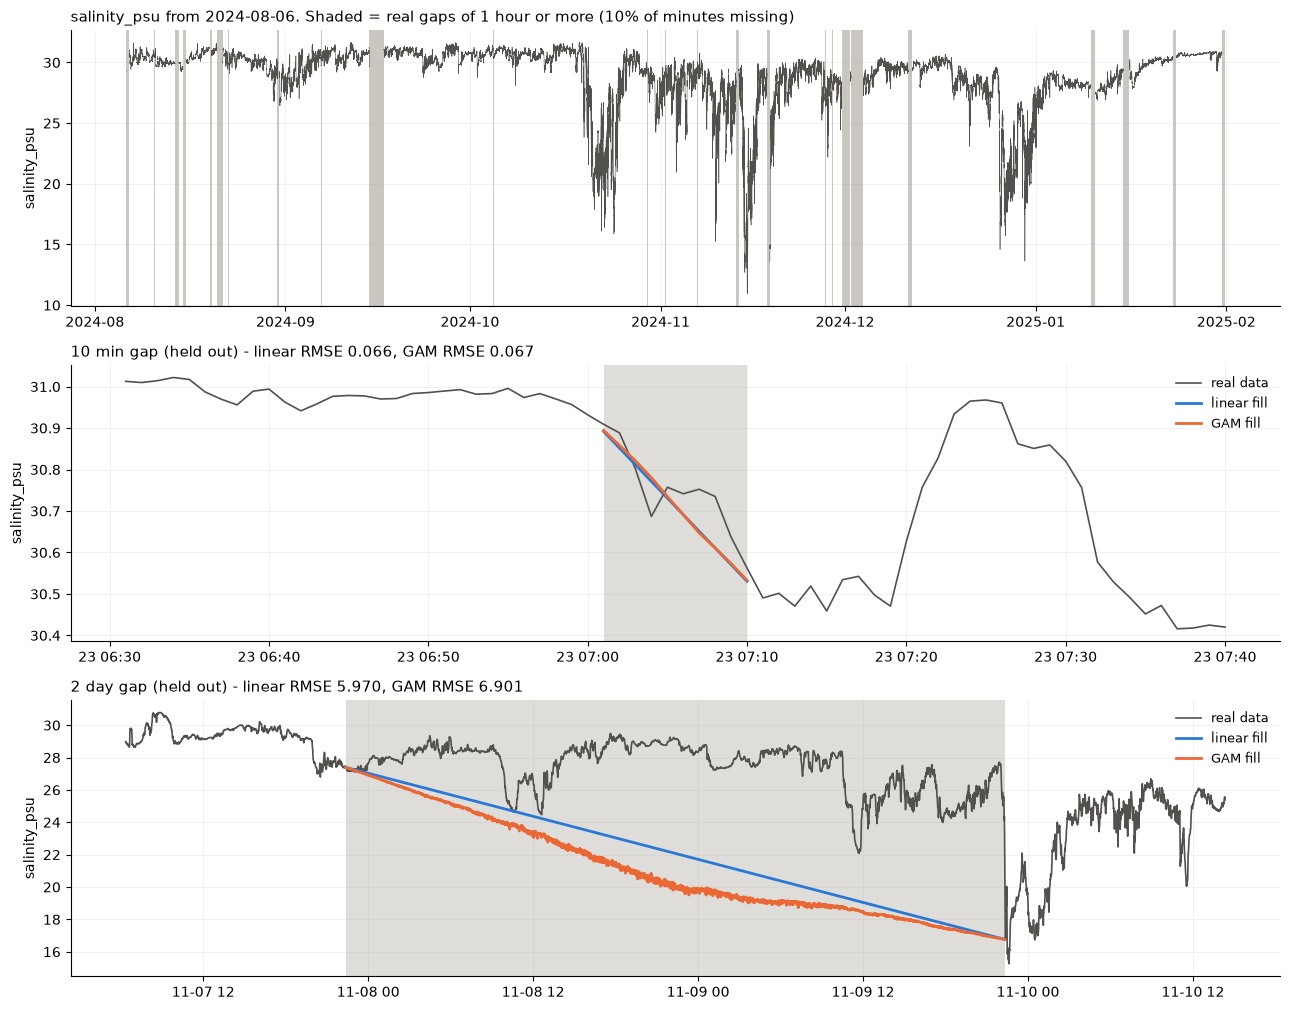

In [24]:
# =====================================================================
# CHANGES: post-July-gap subset | a_first added | wind as u/v vector
#          | pressure added | cyclic smooths on hour + doy
# =====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pygam import LinearGAM, s

TARGET     = 'salinity_psu'
START      = '2024-08-06'          # after the big gap
BLOCK_DAYS = 14
GAPS       = (10, 60, 360, 720, 1440, 2880)
PLOT_GAPS  = (10, 2880)            # 10 min and 2 days
SEEDS      = (0, 1, 2, 3, 4)
N_GAPS, MAX_ROWS, PAD = 150, 60, 180
SHORT_MAX, TRAIN_FRAC, LAM = 60, 0.7, 1000
COMPANIONS = []                    # e.g. ['salinity_psu'] — check availability first
SHORT_USE_DRIVERS = True

C_TRUTH, C_LIN, C_GAM, C_GAP = '#52514e', '#2a78d6', '#eb6834', '#b9b5ac'

D = d.loc[START:].copy()

# SHAPE_COLS  = ['pos_frac', 'dist_edge', 'b_slope', 'a_slope', 'b_last', 'a_first']
SHAPE_COLS  = ['pos_frac', 'dist_edge', 'b_slope', 'a_slope']
LOCAL_COLS  = ['b_d1', 'b_d2', 'a_d1', 'a_d2', 'b_curv', 'a_curv']
DRIVER_COLS = ['hour', 'doy', 'tide', 'airt', 'wind', 'wind_u', 'wind_v',
               'press', 'par', 'rh', 'd_airt', 'd_tide'] + COMPANIONS
CYCLIC = {'hour', 'doy'}

SHORT_COLS = SHAPE_COLS + LOCAL_COLS + (DRIVER_COLS if SHORT_USE_DRIVERS else [])
LONG_COLS  = SHAPE_COLS + DRIVER_COLS
cols_for   = lambda G: SHORT_COLS if G <= SHORT_MAX else LONG_COLS

# wind as a vector instead of speed + raw degrees
_ws = D.wind_speed_ms.values
_wd = np.deg2rad(D.wind_dir_raw_deg.values)

y_all = D[TARGET].values
EXTN = ['hour','doy','tide','airt','wind','wind_u','wind_v','press','par','rh'] + COMPANIONS
ext = np.column_stack([
    D.index.hour + D.index.minute / 60,
    D.index.dayofyear,
    D.tide_m.values,
    D.air_temp_c.values,
    _ws,
    _ws * np.sin(_wd),
    _ws * np.cos(_wd),
    D.pressure_hpa.values,
    D.par_umol_m2_s1.values,
    D.rh_pct.values,
] + [D[c].values for c in COMPANIONS])

ext_ok   = ~np.isnan(ext).any(axis=1)
y_ok     = ~np.isnan(y_all)
block_id = np.arange(len(D)) // (BLOCK_DAYS * 24 * 60)

print(f'{TARGET} from {START}: {len(D)/1440:.0f} days, {block_id.max()+1} blocks')
print(f'short features ({len(SHORT_COLS)}), long features ({len(LONG_COLS)})\n')

def gap_rows(y, i, G, ks):
    b_last, a_first = y[i-1], y[i+G]
    j = i + ks
    e = ext[j]
    out = pd.DataFrame({
        'pos_frac':  (ks + 1) / (G + 1),
        'dist_edge': np.minimum(ks + 1, G - ks),
        'b_last':    b_last,                      # minute right before
        'a_first':   a_first,                     # minute right after
        'b_slope':   y[i-1] - y[i-10],
        'a_slope':   y[i+G+9] - y[i+G],
        'b_d1': y[i-1] - y[i-2],   'b_d2': y[i-2] - y[i-3],
        'a_d1': y[i+G+1] - y[i+G], 'a_d2': y[i+G+2] - y[i+G+1],
        'b_curv': y[i-1] - 2*y[i-2] + y[i-3],
        'a_curv': y[i+G+2] - 2*y[i+G+1] + y[i+G],
        'linear_guess': np.interp(ks + 1, [0, G + 1], [b_last, a_first]),
        'truth': y[j], 'idx': j,
    })
    for n, k in zip(EXTN, range(ext.shape[1])):
        out[n] = e[:, k]
    out['d_airt'] = out['airt'] - ext[i-1, EXTN.index('airt')]
    out['d_tide'] = out['tide'] - ext[i-1, EXTN.index('tide')]
    return out

def build_terms(cols):
    t = None
    for k, c in enumerate(cols):
        try:
            term = s(k, basis='cp') if c in CYCLIC else s(k)
        except Exception:
            term = s(k)
        t = term if t is None else t + term
    return t

def sample_starts(y, G, rng, n):
    starts, tries = [], 0
    while len(starts) < n and tries < n * 400:
        tries += 1
        i = int(rng.integers(PAD, len(y) - G - PAD))
        if block_id[i] != block_id[i + G - 1]:
            continue
        if not (y_ok[i-PAD:i+G+PAD].all() and ext_ok[i-PAD:i+G+PAD].all()):
            continue
        starts.append(i)
    return starts

def one_run(y, G, seed):
    rng = np.random.default_rng(seed)
    starts = sample_starts(y, G, rng, N_GAPS)
    if len(starts) < 8:
        return None
    frames = []
    for gid, i in enumerate(starts):
        ks = np.arange(G) if G <= MAX_ROWS else np.sort(rng.choice(G, MAX_ROWS, replace=False))
        f = gap_rows(y, i, G, ks)
        f['gap'], f['block'], f['start'] = gid, block_id[i], i
        frames.append(f)
    ex = pd.concat(frames, ignore_index=True)
    cols = cols_for(G)
    ex = ex.replace([np.inf, -np.inf], np.nan).dropna(subset=cols + ['truth','linear_guess'])
    blocks = np.unique(ex.block.values)
    if len(blocks) < 4:
        return None
    rng.shuffle(blocks)
    tr_b = set(blocks[:max(1, int(round(TRAIN_FRAC * len(blocks))))])
    tr, te = ex[ex.block.isin(tr_b)], ex[~ex.block.isin(tr_b)]
    if len(tr) < 200 or len(te) < 100:
        return None
    g = LinearGAM(build_terms(cols), lam=LAM).fit(
        tr[cols].values, (tr.truth - tr.linear_guess).values)
    # te = te.assign(pred=te.linear_guess.values + g.predict(te[cols].values))
    corr = g.predict(te[cols].values)
    taper = 2 * np.minimum(te.pos_frac.values, 1 - te.pos_frac.values)
    te = te.assign(pred=te.linear_guess.values + corr * taper)
    r = lambda a: float(np.sqrt(np.mean((te.truth.values - a) ** 2)))
    rec = dict(gap_min=G, seed=seed, n_gaps=len(starts), src_blocks=len(blocks),
               te_blocks=len(blocks)-len(tr_b), n_test=len(te),
               linear=r(te.linear_guess.values), gam=r(te.pred.values),
               sd_truth=float(te.groupby('gap').truth.std().mean()),
               sd_lin=float(te.groupby('gap').linear_guess.std().mean()),
               sd_gam=float(te.groupby('gap').pred.std().mean()))
    return rec, g, cols, te['start'].unique()

def evaluate(y, gaps=GAPS, seeds=SEEDS):
    recs, keep = [], {}
    for G in gaps:
        for sd in seeds:
            out = one_run(y, G, sd)
            if out is None:
                if sd == seeds[0]:
                    print(f'  gap {G:5d} min: not enough clean stretches - skipped')
                continue
            recs.append(out[0])
            keep.setdefault(G, out[1:])
    if not recs:
        print('nothing to report'); return pd.DataFrame(), keep
    r = pd.DataFrame(recs)
    a = r.groupby('gap_min').agg(
        seeds=('seed','size'), gaps=('n_gaps','mean'),
        src_blk=('src_blocks','mean'), test_blk=('te_blocks','mean'),
        linear=('linear','mean'), lin_sd=('linear','std'),
        gam=('gam','mean'), gam_sd=('gam','std'),
        sd_truth=('sd_truth','mean'), sd_lin=('sd_lin','mean'), sd_gam=('sd_gam','mean'))
    a['improve_%'] = (100 * (a.linear - a.gam) / a.linear).round(1)
    a['real?'] = np.where((a.linear - a.gam).abs() > (a.lin_sd + a.gam_sd), 'yes', 'NO - noise')
    print('\nACCURACY  (RMSE, mean +- std over seeds; lower is better)')
    print(a[['seeds','gaps','src_blk','test_blk','linear','lin_sd','gam','gam_sd',
             'improve_%','real?']].round(4).to_string())
    print('\nSPREAD    (within-gap std; ratio 1.00 = same wiggle as reality)')
    sp = a[['sd_truth','sd_lin','sd_gam']].copy()
    sp['lin_ratio'] = (a.sd_lin / a.sd_truth).round(2)
    sp['gam_ratio'] = (a.sd_gam / a.sd_truth).round(2)
    print(sp.round(4).to_string())
    return a, keep

print('running...')
summary, models = evaluate(y_all)

# ---------------- plots ----------------------------------------------
# def fill_one(G, i):
#     model, cols, _ = models[G]
#     f = gap_rows(y_all, i, G, np.arange(G))
#     return (D.index[i:i+G], f.truth.values, f.linear_guess.values,
#             f.linear_guess.values + model.predict(f[cols].values))
def fill_one(G, i):
    model, cols, _ = models[G]
    f = gap_rows(y_all, i, G, np.arange(G))
    corr = model.predict(f[cols].values)
    taper = 2 * np.minimum(f.pos_frac.values, 1 - f.pos_frac.values)
    return (D.index[i:i+G], f.truth.values, f.linear_guess.values,
            f.linear_guess.values + corr * taper)

panels = [G for G in PLOT_GAPS if G in models]
fig, axes = plt.subplots(1 + len(panels), 1, figsize=(13, 3.4 * (1 + len(panels))))
axes = np.atleast_1d(axes)

ax = axes[0]
ax.plot(D.index, y_all, lw=0.4, color=C_TRUTH)
miss = ~y_ok
edges = np.diff(np.concatenate([[0], miss.astype(int), [0]]))
for s0, e0 in zip(np.where(edges == 1)[0], np.where(edges == -1)[0]):
    if e0 - s0 >= 60:
        ax.axvspan(D.index[s0], D.index[min(e0, len(D)-1)], color=C_GAP, alpha=0.75, lw=0)
ax.set_title(f'{TARGET} from {START}. Shaded = real gaps of 1 hour or more '
             f'({100*miss.mean():.0f}% of minutes missing)', loc='left', fontsize=11)
ax.set_ylabel(TARGET)

for ax, G in zip(axes[1:], panels):
    i = int(models[G][2][0])
    t, truth, lin, gam = fill_one(G, i)
    ctx = max(30, G // 3)
    win = slice(i - ctx, i + G + ctx)
    ax.plot(D.index[win], y_all[win], lw=1.2, color=C_TRUTH, label='real data', zorder=3)
    ax.axvspan(t[0], t[-1], color=C_GAP, alpha=0.45, lw=0, zorder=0)
    ax.plot(t, lin, lw=2.0, color=C_LIN, label='linear fill', zorder=4)
    ax.plot(t, gam, lw=2.0, color=C_GAM, label='GAM fill', zorder=5)
    rl = np.sqrt(np.mean((truth - lin) ** 2))
    rg = np.sqrt(np.mean((truth - gam) ** 2))
    lbl = f'{G} min' if G < 1440 else f'{G//1440} day'
    ax.set_title(f'{lbl} gap (held out) - linear RMSE {rl:.3f}, GAM RMSE {rg:.3f}',
                 loc='left', fontsize=11)
    ax.set_ylabel(TARGET)
    ax.legend(loc='best', frameon=False, fontsize=9)

for ax in axes:
    ax.grid(alpha=0.25, lw=0.5)
    for sp_ in ('top','right'):
        ax.spines[sp_].set_visible(False)
fig.tight_layout(); plt.show()

In [46]:
models[10][0].summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     45.3672
Link Function:                     IdentityLink Log Likelihood:                                   890.1634
Number of Samples:                         1010 AIC:                                            -1687.5924
                                                AICc:                                           -1683.0293
                                                GCV:                                                0.0114
                                                Scale:                                              0.1025
                                                Pseudo R-Squared:                                   0.2991
Feature Function                  Lam

/tmp/ipykernel_86/2286290087.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  models[10][0].summary()


In [20]:
%pip install pygam

  Using cached pygam-0.12.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached progressbar2-4.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached scipy-1.16.3-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached python_utils-4.0.0-py3-none-any.whl.metadata (14 kB)
Using cached pygam-0.12.0-py3-none-any.whl (84 kB)
Using cached progressbar2-4.6.0-py3-none-any.whl (104 kB)
Using cached scipy-1.16.3-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (35.7 MB)
Using cached python_utils-4.0.0-py3-none-any.whl (39 kB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.18.0
    Uninstalling scipy-1.18.0:
      Successfully uninstalled scipy-1.18.0━━━━━ 0/4 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pygam]32m3/4 [pygam]
Note: you may need to restart the kernel to use updated packages.


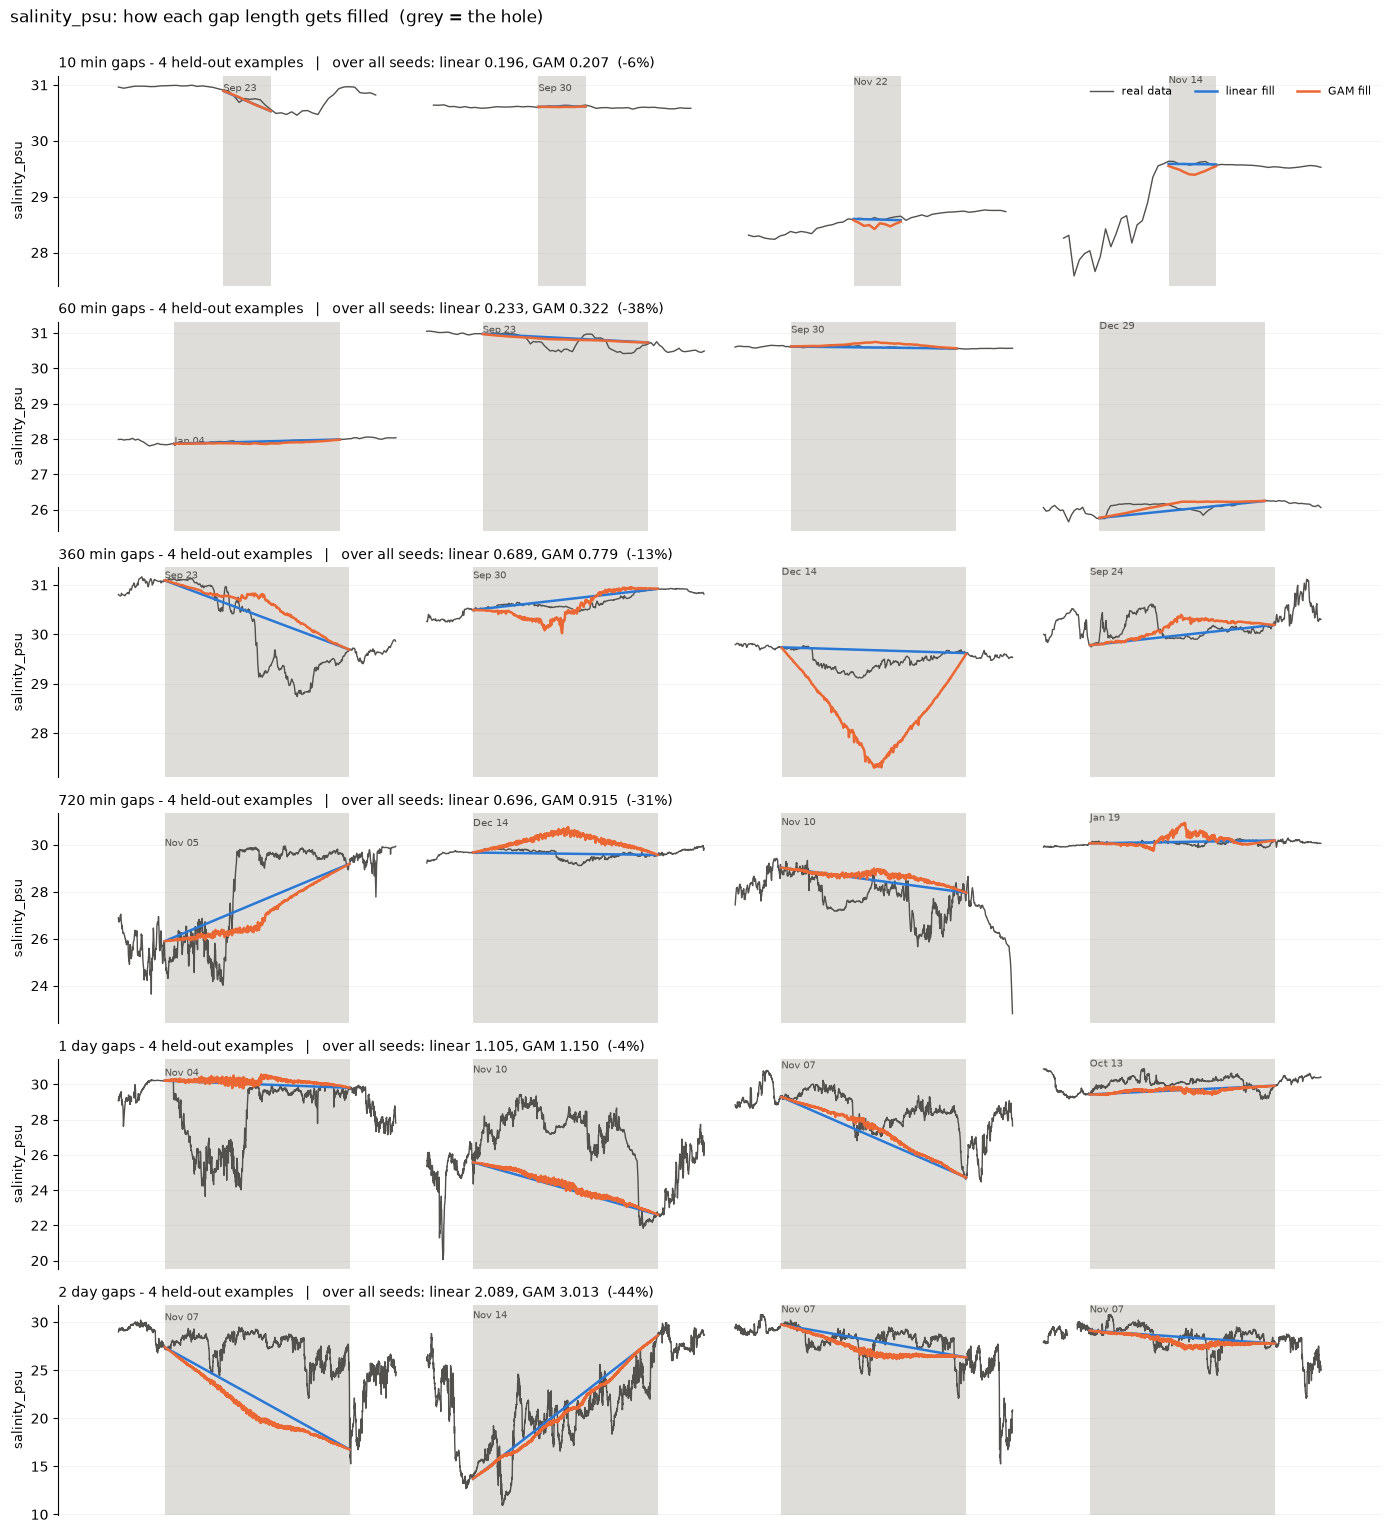

In [22]:
# =====================================================================
# All gap lengths in one figure, one panel per length.
# Each panel shows several held-out gaps side by side (not to scale in
# time - they come from different points in the record).
# =====================================================================
N_EXAMPLES = 4          # how many example gaps to show per length

show = [G for G in GAPS if G in models]
fig, axes = plt.subplots(len(show), 1, figsize=(14, 2.6 * len(show)), squeeze=False)
axes = axes[:, 0]

for ax, G in zip(axes, show):
    starts = models[G][2][:N_EXAMPLES]
    ctx = max(20, G // 4)
    offset = 0
    rl_all, rg_all = [], []

    for n, i in enumerate(starts):
        i = int(i)
        t, truth, lin, gam = fill_one(G, i)
        win = slice(i - ctx, i + G + ctx)
        seg = y_all[win]
        x = np.arange(len(seg)) + offset          # fake x-axis so panels line up
        xg = x[ctx:ctx + G]

        ax.axvspan(xg[0], xg[-1], color=C_GAP, alpha=0.45, lw=0, zorder=0)
        ax.plot(x, seg, lw=1.0, color=C_TRUTH, zorder=3,
                label='real data' if n == 0 else None)
        ax.plot(xg, lin, lw=1.8, color=C_LIN, zorder=4,
                label='linear fill' if n == 0 else None)
        ax.plot(xg, gam, lw=1.8, color=C_GAM, zorder=5,
                label='GAM fill' if n == 0 else None)

        ax.text(xg[0], ax.get_ylim()[1], D.index[i].strftime('%b %d'),
                fontsize=7, color=C_TRUTH, va='top', ha='left')

        rl_all.append(np.sqrt(np.mean((truth - lin) ** 2)))
        rg_all.append(np.sqrt(np.mean((truth - gam) ** 2)))
        offset += len(seg) + max(10, G // 6)      # spacer between examples

    row = summary.loc[G] if G in summary.index else None
    lbl = f'{G} min' if G < 1440 else f'{G // 1440} day'
    title = f'{lbl} gaps - {len(starts)} held-out examples'
    if row is not None:
        title += (f'   |   over all seeds: linear {row.linear:.3f}, '
                  f'GAM {row.gam:.3f}  ({row["improve_%"]:+.0f}%)')
    ax.set_title(title, loc='left', fontsize=10)
    ax.set_ylabel(TARGET, fontsize=9)
    ax.set_xticks([])
    ax.grid(alpha=0.2, lw=0.5, axis='y')
    for sp_ in ('top', 'right', 'bottom'):
        ax.spines[sp_].set_visible(False)
    if G == show[0]:
        ax.legend(loc='upper right', frameon=False, fontsize=8, ncol=3)

fig.suptitle(f'{TARGET}: how each gap length gets filled  (grey = the hole)',
             fontsize=12, x=0.01, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [21]:
G = 2880
model, cols, starts = models[G]
i = int(starts[0])
f = gap_rows(y_all, i, G, np.arange(G))
corr = model.predict(f[cols].values)

print('correction at gap edges and middle:')
print(f'  first minute : {corr[0]:+.4f}   (should be ~0)')
print(f'  last  minute : {corr[-1]:+.4f}   (should be ~0)')
print(f'  middle       : {corr[G//2]:+.4f}')
print(f'  mean         : {corr.mean():+.4f}')
print(f'  std          : {corr.std():.4f}')
print()
print(f'truth at edges : {f.truth.values[0]:.3f}, {f.truth.values[-1]:.3f}')
print(f'b_last/a_first : {f.b_last.iloc[0]:.3f}, {f.a_first.iloc[0]:.3f}')
print(f'linear at edges: {f.linear_guess.values[0]:.3f}, {f.linear_guess.values[-1]:.3f}')
print()
print('training residual scale for this length:')
print(f'  cols used ({len(cols)}): {cols}')

correction at gap edges and middle:
  first minute : -0.5898   (should be ~0)
  last  minute : -0.7593   (should be ~0)
  middle       : -0.6919
  mean         : -0.7976
  std          : 0.1425

truth at edges : 11.128, 11.133
b_last/a_first : 11.131, 11.091
linear at edges: 11.131, 11.091

training residual scale for this length:
  cols used (18): ['pos_frac', 'dist_edge', 'b_slope', 'a_slope', 'b_last', 'a_first', 'hour', 'doy', 'tide', 'airt', 'wind', 'wind_u', 'wind_v', 'press', 'par', 'rh', 'd_airt', 'd_tide']


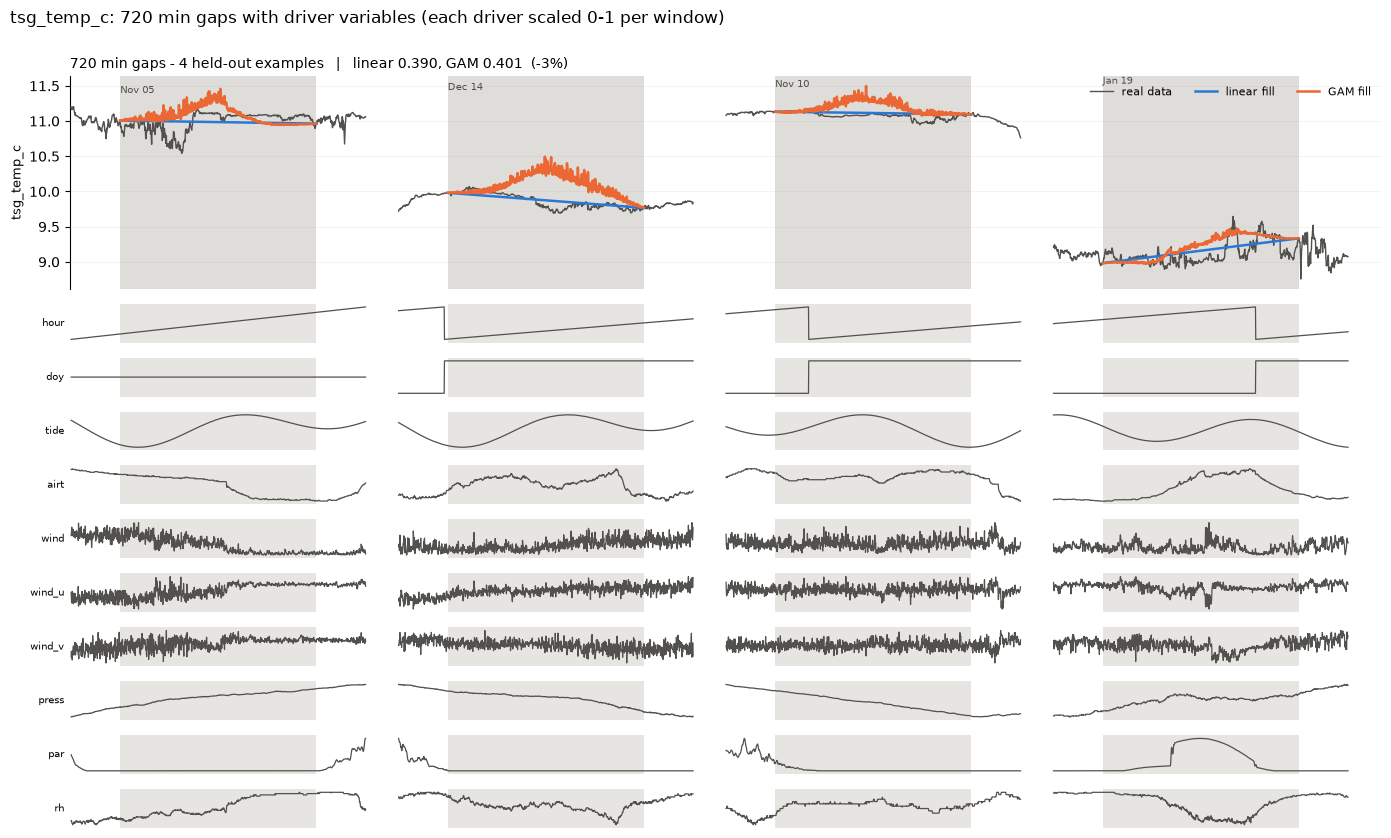

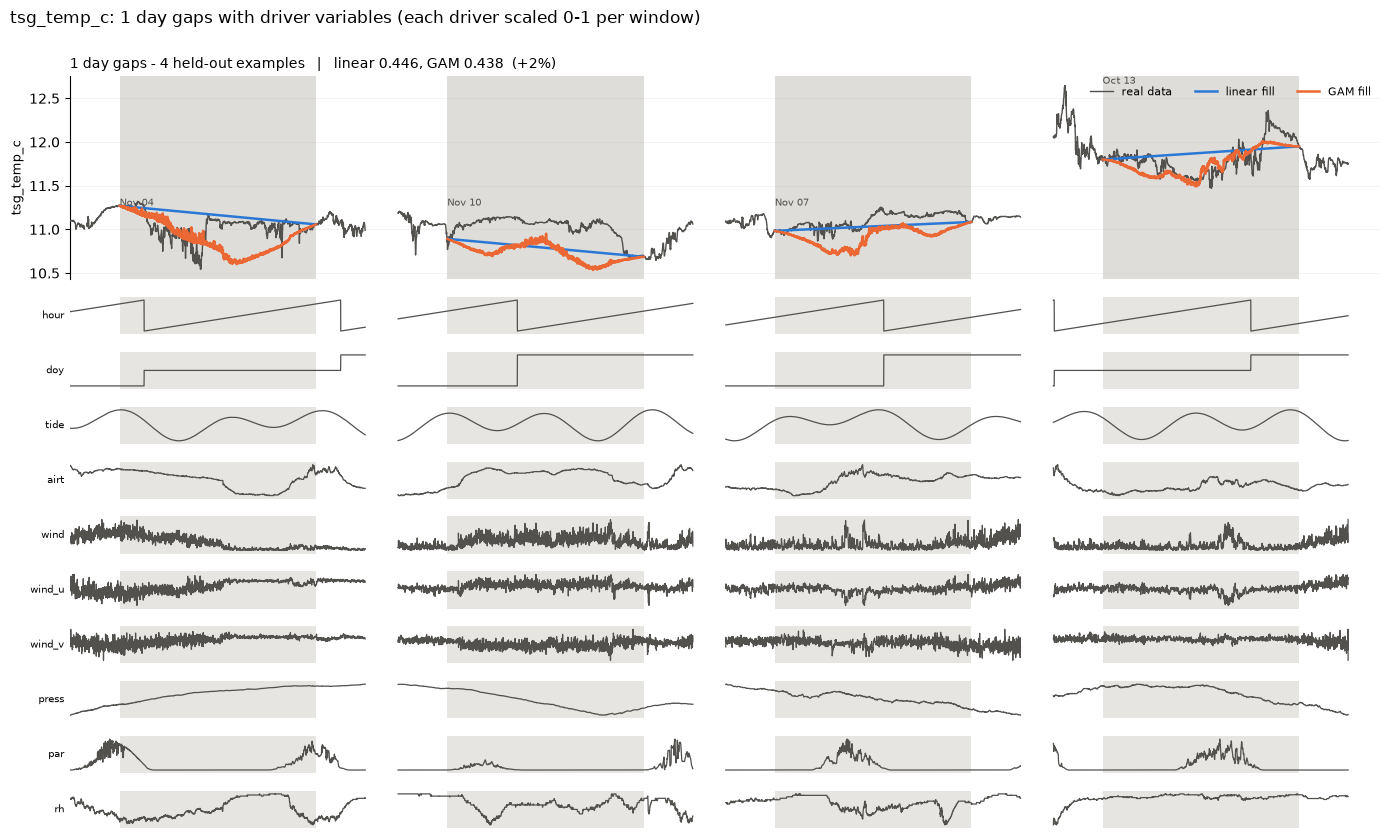

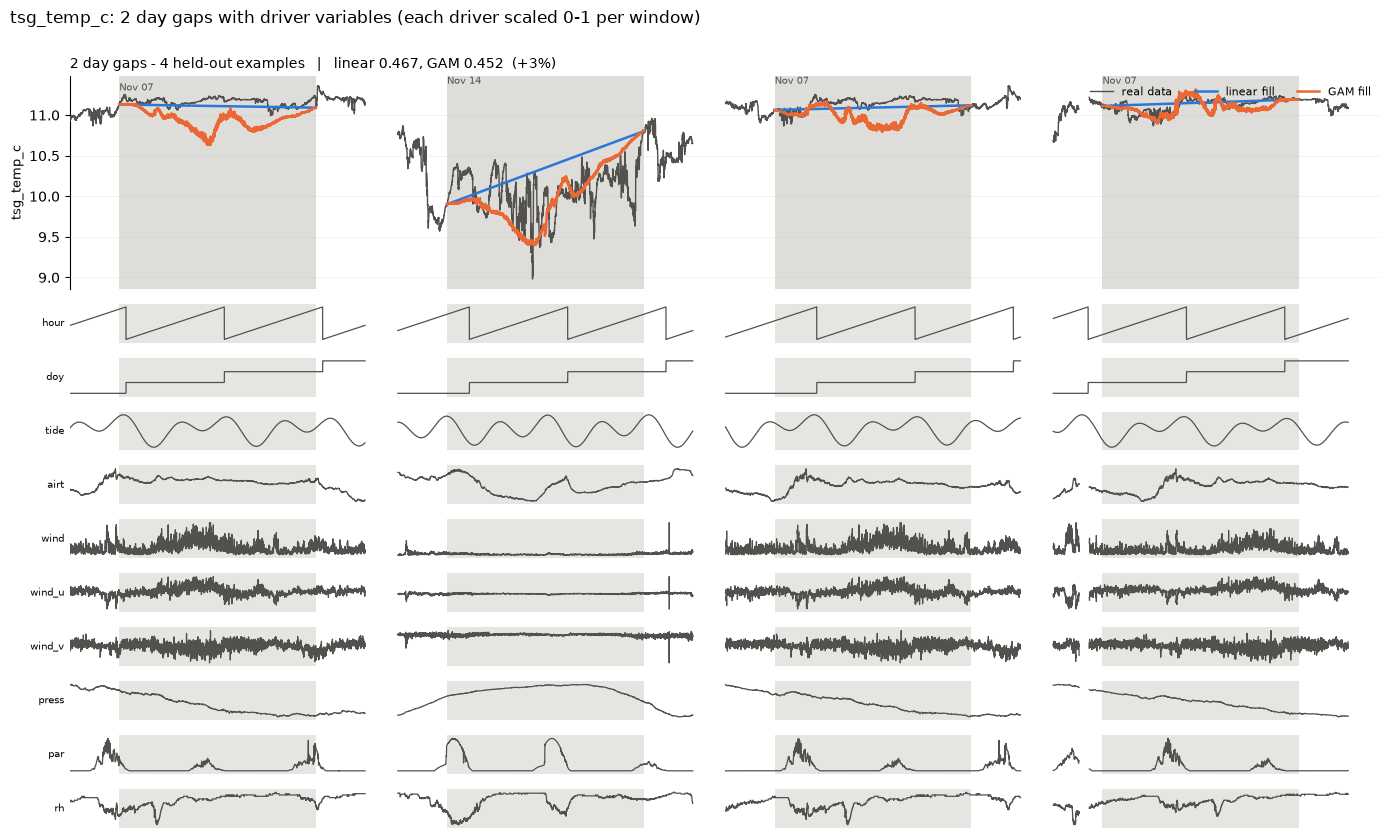

In [24]:
# =====================================================================
# Target panel + one thin strip per driver, sharing the same x layout.
# Drivers are scaled 0-1 within each window so they fit thin strips —
# shape is readable, absolute values are not.
# =====================================================================
N_EXAMPLES = 4
STRIP_VARS = [c for c in DRIVER_COLS if c in EXTN]   # plottable drivers

def plot_with_drivers(G, n_ex=N_EXAMPLES):
    if G not in models:
        print(f'{G}: no model'); return
    starts = [int(i) for i in models[G][2][:n_ex]]
    ctx = max(20, G // 4)

    nrow = 1 + len(STRIP_VARS)
    h = [3.0] + [0.55] * len(STRIP_VARS)
    fig, axes = plt.subplots(nrow, 1, figsize=(14, sum(h)),
                             gridspec_kw={'height_ratios': h}, squeeze=False)
    axes = axes[:, 0]
    ax0 = axes[0]

    offset = 0
    spans = []
    for n, i in enumerate(starts):
        t, truth, lin, gam = fill_one(G, i)
        win = slice(i - ctx, i + G + ctx)
        seg = y_all[win]
        x = np.arange(len(seg)) + offset
        xg = x[ctx:ctx + G]
        spans.append((i, win, x, xg))

        ax0.axvspan(xg[0], xg[-1], color=C_GAP, alpha=0.45, lw=0, zorder=0)
        ax0.plot(x, seg, lw=1.0, color=C_TRUTH, zorder=3,
                 label='real data' if n == 0 else None)
        ax0.plot(xg, lin, lw=1.8, color=C_LIN, zorder=4,
                 label='linear fill' if n == 0 else None)
        ax0.plot(xg, gam, lw=1.8, color=C_GAM, zorder=5,
                 label='GAM fill' if n == 0 else None)
        ax0.text(xg[0], ax0.get_ylim()[1], D.index[i].strftime('%b %d'),
                 fontsize=7, color=C_TRUTH, va='top', ha='left')
        offset += len(seg) + max(10, G // 6)

    row = summary.loc[G] if G in summary.index else None
    lbl = f'{G} min' if G < 1440 else f'{G // 1440} day'
    title = f'{lbl} gaps - {len(starts)} held-out examples'
    if row is not None:
        title += (f'   |   linear {row.linear:.3f}, GAM {row.gam:.3f}'
                  f'  ({row["improve_%"]:+.0f}%)')
    ax0.set_title(title, loc='left', fontsize=10)
    ax0.set_ylabel(TARGET, fontsize=9)
    ax0.legend(loc='upper right', frameon=False, fontsize=8, ncol=3)

    # driver strips
    for ax, name in zip(axes[1:], STRIP_VARS):
        k = EXTN.index(name)
        for (i, win, x, xg) in spans:
            v = ext[win, k].astype(float)
            lo, hi = np.nanmin(v), np.nanmax(v)
            vs = (v - lo) / (hi - lo) if hi > lo else np.full_like(v, 0.5)
            ax.axvspan(xg[0], xg[-1], color=C_GAP, alpha=0.35, lw=0, zorder=0)
            ax.plot(x, vs, lw=0.9, color=C_TRUTH, zorder=2)
        ax.set_ylabel(name, fontsize=7, rotation=0, ha='right', va='center')
        ax.set_ylim(-0.1, 1.1)
        ax.set_yticks([])

    for ax in axes:
        ax.set_xticks([])
        ax.set_xlim(-5, offset)
        ax.grid(alpha=0.2, lw=0.5, axis='y')
        for sp_ in ('top', 'right', 'bottom', 'left'):
            ax.spines[sp_].set_visible(False)
    axes[0].spines['left'].set_visible(True)

    fig.suptitle(f'{TARGET}: {lbl} gaps with driver variables '
                 f'(each driver scaled 0-1 per window)',
                 fontsize=12, x=0.01, ha='left')
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

for G in (720, 1440, 2880):
    plot_with_drivers(G)